This Jupyter Notebook shows the analysis of one participant's brain activation (sub-5404) using functional magnetic resonance imaging (fMRI) during a memory encoding task, which is further described below. 

We used raw data from an open-access dataset [(OpenNeuro ds003789)](https://github.com/OpenNeuroDatasets/ds003789.git). We used snapshot 2.0.0, corresponding to Git commit 26d526316b558d23eea68db5cd48736950fa22ca, which follows the BIDS 1.0.1 specification and can be downloaded using Datalad. 

We use a General Linear Model (GLM) to estimate the brain's response during different experimental conditions (i.e. phases of the task). In this case, we are interested in contrasting activations from Time 1 and Time 3, which represent repetition-related changes in brain activity. We hypothesize that there will generally be less activation at Time 3 than at Time 1 (rep1 > rep 3) in regions related to memory encoding because there has been repeated exposure to the stimuli, and therefore, participants will have better encoded the word-list stimuli, thus requiring less effort.

The fMRI task used in this study was composed of two phases: 1) memory encoding, and 2) retrieval. During the encoding phase, participants were presented with nine different lists of words over nine runs (one word list per run). Each list was composed of eight words of the same semantic category. Each list was presented three times (Time 1/rep1, Time 2/rep2, Time 3/rep3). See the figure below for a more detailed task description. [Link towards the original article.](https://www.sciencedirect.com/science/article/pii/S1053811922005596?ref=pdf_download&fr=RR-2&rr=94da58ab3a47a308)

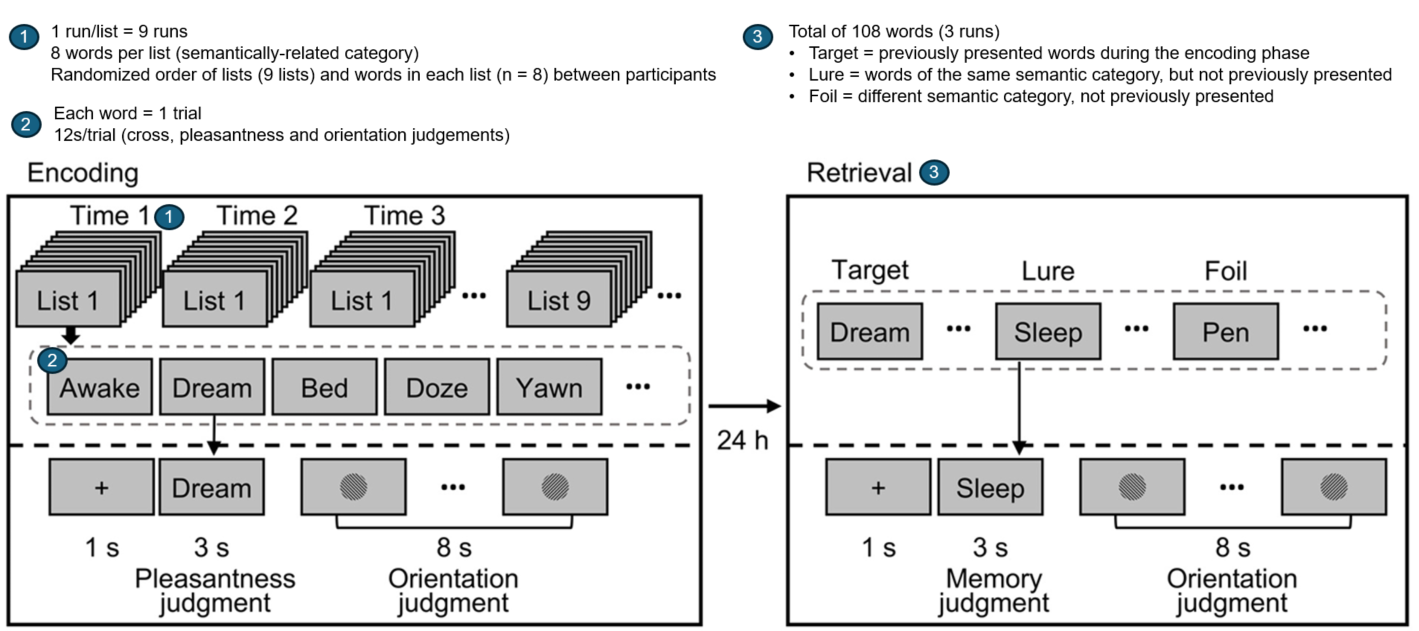

For the current exercise, we use fMRI images from one subject, across all nine runs, acquired during the encoding phase. 

# Step 1: Laying the groundwork
## 1.1 Import the necessary libraries

In [1]:
import os
import glob
import numpy as np
import pandas as pd
import nibabel as nib
from pathlib import Path
from scipy.stats import norm
import matplotlib.pyplot as plt
from nilearn.glm import threshold_stats_img
from nilearn.image import mean_img, load_img
from nilearn import image, masking, input_data
from nilearn.reporting import get_clusters_table
from nilearn.glm.first_level import FirstLevelModel
from nilearn.plotting import plot_anat, plot_img, plot_stat_map, show, plot_design_matrix, view_img

print("Bibliothèques importées avec succès.")


Bibliothèques importées avec succès.


/tmp/ipykernel_1271/1160887791.py:11: FutureWarning: The import path 'nilearn.input_data' is deprecated in version 0.9. Importing from 'nilearn.input_data' will be possible at least until release 0.13.0. Please import from 'nilearn.maskers' instead.
  from nilearn import image, masking, input_data


## 1.2 Access the data
We will need the functional images (.nii.gz) and events files (.tsv) for each run (n = 9) for the selected subject (sub-5404, in this case). We can also load the anatomical T1 image of the participant. To input the data, we provide a list of paths to files (here, relative to my own device) that respect the Brain Imaging Data Structure (BIDS) organization principles.

Pour cloner la banque de donnée dans l'expérience, il faut utiliser un dataset (ds003789) de OpenNeuro. Pour l'installer dans son directory/fichier, effectuez cette prochaine cellule.

In [3]:
import subprocess
from pathlib import Path

dataset_id = "ds003789"

dataset_url = f"https://github.com/OpenNeuroDatasets/{dataset_id}.git"
result = subprocess.run(f"datalad install {dataset_url}", shell=True)


Cette cellule crée un chemin absolu vers le dossier du dataset sur l'ordinateur de l'utilisateur et vérifie qu'il a bien été installé. Ensuite, elle télécharge uniquement les fichiers nécessaires à l'analyse (images d'encodage (IRMf), fichiers d'événements et image anatomique) plutôt que l'ensemble du dataset.

In [ ]:
import os 
dataset_dir = Path(f"./{dataset_id}").absolute()

if not dataset_dir.exists():
    raise FileNotFoundError(
        f"Dataset directory '{dataset_dir}' does not exist. "
        "Create it before running DataLad install."
    )
else:
    print(f"Dataset {dataset_id} fetched locally")

subprocess.run(f"datalad get -d {dataset_dir} {dataset_dir}/sub-5404/func/*encoding*nii.gz", shell=True) #images IRMf
subprocess.run(f"datalad get -d {dataset_dir} {dataset_dir}/sub-5404/func/*encoding*tsv", shell=True) #TSV
subprocess.run(f"datalad get -d {dataset_dir} {dataset_dir}/sub-5404/anat/*T1w.nii.gz", shell=True) #images anatomiques

Dataset ds003789 fetched locally
action summary:
  get (notneeded: 9)
action summary:
  get (notneeded: 9)


CompletedProcess(args='datalad get -d /home/atyanna/projet3019/ds003789 /home/atyanna/projet3019/ds003789/sub-5404/anat/*T1w.nii.gz', returncode=0)

Les chemins vers les fichiers sont construits pour pouvoir être reproductible. Les fichiers sont ensuite stockés dans des variables afin de pouvoir les utiliser plus tard.

In [4]:
# functional images 
fmri_imgs = sorted(glob.glob("*ds003789/sub-5404/func/sub-5404_task-encoding_run-0*_bold.nii.gz"))
fmri_imgs


['ds003789/sub-5404/func/sub-5404_task-encoding_run-01_bold.nii.gz',
 'ds003789/sub-5404/func/sub-5404_task-encoding_run-02_bold.nii.gz',
 'ds003789/sub-5404/func/sub-5404_task-encoding_run-03_bold.nii.gz',
 'ds003789/sub-5404/func/sub-5404_task-encoding_run-04_bold.nii.gz',
 'ds003789/sub-5404/func/sub-5404_task-encoding_run-05_bold.nii.gz',
 'ds003789/sub-5404/func/sub-5404_task-encoding_run-06_bold.nii.gz',
 'ds003789/sub-5404/func/sub-5404_task-encoding_run-07_bold.nii.gz',
 'ds003789/sub-5404/func/sub-5404_task-encoding_run-08_bold.nii.gz',
 'ds003789/sub-5404/func/sub-5404_task-encoding_run-09_bold.nii.gz']

In [ ]:
# events files 
events_files = sorted(glob.glob("*ds003789/sub-5404/func/sub-5404_task-encoding_run-0*_events.tsv"))
events_files

In [5]:
# anatomical image
anat_img = glob.glob(str(dataset_dir / "sub-5404" / "anat" / "*T1w.nii.gz"))[0]
anat_img

'/home/atyanna/projet3019/ds003789/sub-5404/anat/sub-5404_T1w.nii.gz'

### 1.2 Tâche 2-A : Changement de participant (dataset original - ds003789)

À la suite de l'oral de mi-session, il a été proposé d'essayer de changer de participant comme tâche principale puisque c'était plus atteignable. Le notebook original était codé pour un seul participant (sub-5404) et les fichiers intégraient le nom du sujet dans le chemin. Cette section et les modifications subsécantes permettent de changer de participant très facilement, soit changer la variable subj. 

Ces changements n'ont malheureusement pas étés ajoutés peu à peu dans le github puisque j'ai commencer à push les modifications de mon notebook régulièrement sur github après avoir accomplis cette tâche.



In [ ]:
import os 
dataset_dir = Path(f"./{dataset_id}").absolute()

if not dataset_dir.exists():
    raise FileNotFoundError(
        f"Dataset directory '{dataset_dir}' does not exist. "
        "Create it before running DataLad install."
    )
else:
    print(f"Dataset {dataset_id} fetched locally")

subj = "5404"


In [ ]:
import subprocess
from pathlib import Path

#Création du chemin et vérification 
#Vérification 
subprocess.run(f"datalad get -d {dataset_dir} {dataset_dir}/sub-{subj}/func/*encoding*nii.gz", shell=True) #images IRMf
subprocess.run(f"datalad get -d {dataset_dir} {dataset_dir}/sub-{subj}/func/*encoding*tsv", shell=True) #TSV
subprocess.run(f"datalad get -d {dataset_dir} {dataset_dir}/sub-{subj}/anat/*T1w.nii.gz", shell=True) #images anatomiques



action summary:
  get (notneeded: 9)
action summary:
  get (notneeded: 9)


CompletedProcess(args='datalad get -d /home/atyanna/projet3019/ds003789 /home/atyanna/projet3019/ds003789/sub-5404/anat/*T1w.nii.gz', returncode=0)

In [ ]:
#Changer entre les participants et trouver fichiers irmf, event files et anatomical images

#Télécharger les données
#créer le lien 
lien_fmri_imgs = f"{dataset_dir}/sub-{subj}/func/sub-{subj}_task-encoding_run-0*_bold.nii.gz"
fmri_imgs = sorted(glob.glob(lien_fmri_imgs))
fmri_imgs

#events files 
lien_events_files = f"{dataset_dir}/sub-{subj}/func/sub-{subj}_task-encoding_run-0*_events.tsv"
events_files = sorted(glob.glob(lien_events_files))
events_files

#anatomical image
lien_anat_img = f"{dataset_dir}/sub-{subj}/anat/sub-{subj}_T1w.nii.gz"
anat_img = glob.glob(lien_anat_img)[0]
anat_img



'/home/atyanna/projet3019/ds003789/sub-5404/anat/sub-5404_T1w.nii.gz'

### 1.2 Tâche 2-B : Essayer d'appliquer le processus à un autre dataset (nouveau dataset - ds002731)

Le deuxième dataset provient de l'article *"Multiple interactive memory representations underlie the induction of false memory"* (Zhu et al., 2019). Contrairement au dataset original où les conditions expérimentales (rep1/rep2/rep3) sont définies au niveau des trials, dans ce dataset les conditions sont définies au niveau du participant : chaque participant appartient à un groupe (audio-visual, visual-visual, audio-audio) selon la modalité sensorielle utilisée lors de l'apprentissage et du test.

Pour cette raison, au lieu de comparer des répétitions à l'intérieur d'un même sujet, la « comparaison » est entre deux sujets de groupes différents : un sujet visual-visual (sub-5024) et un sujet audio-visual (sub-3724).

Pour changer de participants, il faut modifier les variables « subj1 » et « subj2 » dans la cellule suivante.

> **À NOTER :**
> Si les résultats du deuxième dataset (ds002731) ne vous est pas pertinent, vous pouvez ignorer toutes les cellules intitullées « Tâche 2-B (nouveau dataset)... » et continuer dans la prochaine section. Cette tâche (2-B) peut entièrement fonctionner indépendamment du dataset original. À l'inverse, si le dataset original ne vous intéresse pas, vous pouvez run seulement les cellules de la tâche 2-B. La tâche 2-B sera toujours à la fin de chaque section pour faciliter la lecture.

In [5]:
import subprocess
from pathlib import Path

dataset_id = "ds002731"

dataset_url = f"https://github.com/OpenNeuroDatasets/{dataset_id}.git"
result = subprocess.run(f"datalad install {dataset_url}", shell=True)


Pour choisir le participant, j'ai été regarder manuellement dans le document 
participants.tsv pour trouver deux participants avec des conditions différentes 
(auditory-visual ou visual-visual, les seuls conditions disponibles).

In [ ]:
import os 
dataset_dir = Path(f"./{dataset_id}").absolute()

if not dataset_dir.exists():
    raise FileNotFoundError(
        f"Dataset directory '{dataset_dir}' does not exist. "
        "Create it before running DataLad install."
    )
else:
    print(f"Dataset {dataset_id} fetched locally")


subj1 = "5024" #visual-visual
subj2 = "3724" # audio-visual



Dataset ds002731 fetched locally


In [ ]:
import subprocess
from pathlib import Path

#Création du chemin et vérification 
#Vérification 

#SUJET 1
subprocess.run(f"datalad get -d {dataset_dir} {dataset_dir}/sub-{subj1}/func/*encoding*nii.gz", shell=True) #images IRMf
subprocess.run(f"datalad get -d {dataset_dir} {dataset_dir}/sub-{subj1}/func/*encoding*tsv", shell=True) #TSV
subprocess.run(f"datalad get -d {dataset_dir} {dataset_dir}/sub-{subj1}/anat/*T1w.nii.gz", shell=True) #images anatomiques

#SUJET 2
subprocess.run(f"datalad get -d {dataset_dir} {dataset_dir}/sub-{subj2}/func/*encoding*nii.gz", shell=True) #images IRMf
subprocess.run(f"datalad get -d {dataset_dir} {dataset_dir}/sub-{subj2}/func/*encoding*tsv", shell=True) #TSV
subprocess.run(f"datalad get -d {dataset_dir} {dataset_dir}/sub-{subj2}/anat/*T1w.nii.gz", shell=True) #images anatomiques



action summary:
  get (notneeded: 3)
action summary:
  get (notneeded: 3)
action summary:
  get (notneeded: 3)
action summary:
  get (notneeded: 3)


CompletedProcess(args='datalad get -d /home/atyanna/projet3019/ds002731 /home/atyanna/projet3019/ds002731/sub-3724/anat/*T1w.nii.gz', returncode=0)

In [ ]:
#Permet de changer entre les participants et trouver fichiers irmf, event files et anatomical images

#SUJET 1
#Télécharger les données
#créer le lien 
lien_fmri_imgs1 = f"{dataset_dir}/sub-{subj1}/func/sub-{subj1}_task-encoding_run-0*_bold.nii.gz"
fmri_imgs1 = sorted(glob.glob(lien_fmri_imgs1))

#events files 
lien_events_files1 = f"{dataset_dir}/sub-{subj1}/func/sub-{subj1}_task-encoding_run-0*_events.tsv"
events_files1 = sorted(glob.glob(lien_events_files1))

# #anatomical image
lien_anat_img1 = f"{dataset_dir}/sub-{subj1}/anat/sub-{subj1}_T1w.nii.gz"
anat_img1 = glob.glob(lien_anat_img1)[0]


#SUJET 2
#Télécharger les données
#créer le lien 
lien_fmri_imgs2 = f"{dataset_dir}/sub-{subj2}/func/sub-{subj2}_task-encoding_run-0*_bold.nii.gz"
fmri_imgs2 = sorted(glob.glob(lien_fmri_imgs2))

#events files 
lien_events_files2 = f"{dataset_dir}/sub-{subj2}/func/sub-{subj2}_task-encoding_run-0*_events.tsv"
events_files2 = sorted(glob.glob(lien_events_files2))

# #anatomical image
lien_anat_img2 = f"{dataset_dir}/sub-{subj2}/anat/sub-{subj2}_T1w.nii.gz"
anat_img2 = glob.glob(lien_anat_img2)[0]


## 1.3 "Preprocess" the images
To do so, we can clean and smooth the functional images. Cleaning refers to denoising and temporal filtering of the fMRI signal, and smoothing blurs the images by averaging nearby voxels to increase the signal-to-noise ratio. From here, we will use the cleaned and smoothed images for further analyses.
Note: It would have been preferable to use properly preprocessed data from fMRIPrep, but it was unavailable for the current dataset. 

NOTE : Le processus peut durer entre 20 minutes et 40 minutes.

In [ ]:
from tqdm.notebook import tqdm

cleaned_imgs = [image.clean_img(img, high_pass=0.01, t_r=2, standardize=True) 
                for img in tqdm(fmri_imgs, desc="Cleaning")]

smoothed_imgs = [image.smooth_img(img, 5.) 
                 for img in tqdm(cleaned_imgs, desc="Smoothing")]

### 1.3 Tâche 2-B (nouveau dataset)
Le même prétraitement est appliqué aux sujets du dataset 2. Cette étape dure environ 16-25 minutes. Si les résultats du deuxième dataset (ds00237) ne vous est pas pertinent. Vous poouvez ignorer toutes les cellules en lien avec la tâche 2-B et continuer dans la prochaine section, elle peut fonctionner indépendamment du dataset original. La tâche 2-B sera toujours à la fin de chaque section pour faciliter la lecture.

> **À NOTER :**
> N'hésitez pas à passer à la section « Step 2: Familiarization with the data, 2.1 Display the subject's anatomy »

In [9]:
from tqdm.notebook import tqdm

#SUJET 1
cleaned_imgs1 = [image.clean_img(img, high_pass=0.01, t_r=2, standardize=True) 
                for img in tqdm(fmri_imgs1, desc="Cleaning")]

smoothed_imgs1 = [image.smooth_img(img, 5.) 
                 for img in tqdm(cleaned_imgs1, desc="Smoothing")]

Cleaning:   0%|          | 0/3 [00:00<?, ?it/s]

/tmp/ipykernel_1271/59159296.py:4: FutureWarning: boolean values for 'standardize' will be deprecated in nilearn 0.15.0.
Use 'zscore_sample' instead of 'True' or use 'None' instead of 'False'.
  cleaned_imgs1 = [image.clean_img(img, high_pass=0.01, t_r=2, standardize=True)
/tmp/ipykernel_1271/59159296.py:4: FutureWarning: The default strategy for standardize is currently 'zscore' which incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.14.0, the default strategy will be replaced by the new strategy, the 'zscore' option will be removed. and using standardize=True will fall back to 'zscore_sample'.To avoid this warning, please use 'zscore_sample' instead.
  cleaned_imgs1 = [image.clean_img(img, high_pass=0.01, t_r=2, standardize=True)


Smoothing:   0%|          | 0/3 [00:00<?, ?it/s]

In [10]:
#SUJET 2
cleaned_imgs2 = [image.clean_img(img, high_pass=0.01, t_r=2, standardize=True) 
                for img in tqdm(fmri_imgs2, desc="Cleaning")]

smoothed_imgs2 = [image.smooth_img(img, 5.) 
                 for img in tqdm(cleaned_imgs2, desc="Smoothing")]

Cleaning:   0%|          | 0/3 [00:00<?, ?it/s]

/tmp/ipykernel_1271/4073067232.py:2: FutureWarning: boolean values for 'standardize' will be deprecated in nilearn 0.15.0.
Use 'zscore_sample' instead of 'True' or use 'None' instead of 'False'.
  cleaned_imgs2 = [image.clean_img(img, high_pass=0.01, t_r=2, standardize=True)
/tmp/ipykernel_1271/4073067232.py:2: FutureWarning: The default strategy for standardize is currently 'zscore' which incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.14.0, the default strategy will be replaced by the new strategy, the 'zscore' option will be removed. and using standardize=True will fall back to 'zscore_sample'.To avoid this warning, please use 'zscore_sample' instead.
  cleaned_imgs2 = [image.clean_img(img, high_pass=0.01, t_r=2, standardize=True)


Smoothing:   0%|          | 0/3 [00:00<?, ?it/s]

# Step 2: Familiarization with the data 
## 2.1 Display the subject's anatomy
Useful to use as a background as the images have not been normalized to MNI space. 

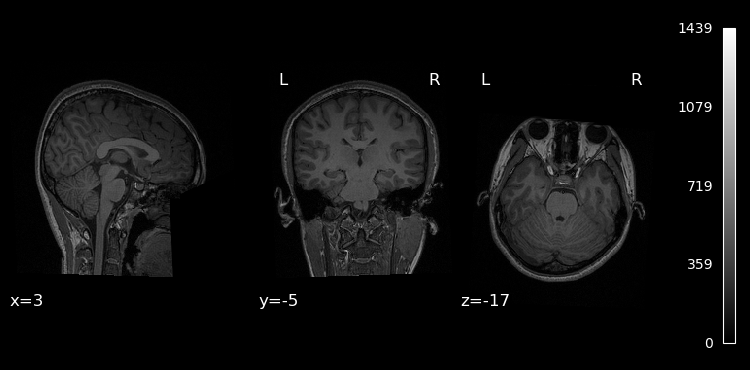

In [14]:
plot_anat(anat_img, colorbar=True, cbar_tick_format="%i", draw_cross=False)

### 2.1 Tâche 2-B (nouveau dataset)

Les images anatomiques des deux sujets sont affichées aux mêmes coordonnées MNI (0, 0, 0) pour faciliter la comparaison visuelle. Les différences de forme reflètent la variabilité naturelle entre individus.

> **À NOTER :**
> N'hésitez pas à passer à la section « 2.2 Display the mean functional image »

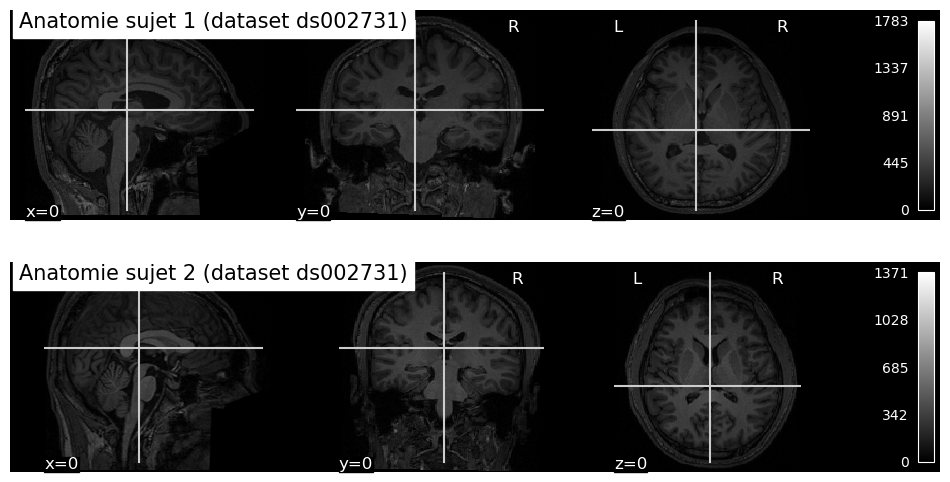

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6))
coordonnees = (0, 0, 0)

plot_anat(anat_img1, colorbar=True, cbar_tick_format="%i", axes=axes[0], title=("Anatomie sujet 1 (ds002731)"), cut_coords=coordonnees, draw_cross=False)
plot_anat(anat_img2, colorbar=True, cbar_tick_format="%i", axes=axes[1], title=("Anatomie sujet 2 (ds002731)"), cut_coords=coordonnees, draw_cross=False)

plt.show()



## 2.2 Display the mean functional image
This is useful for plotting purposes to use as a background and to create the mask.

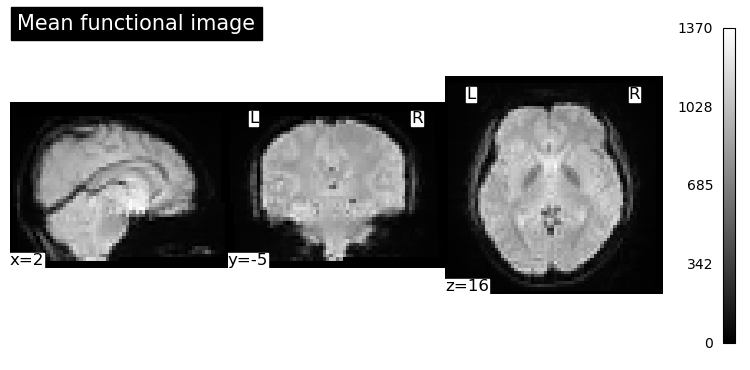

In [16]:
mean_img_result = mean_img(fmri_imgs, copy_header=True)
plot_img(mean_img_result, title="Mean functional image", colorbar=True, cbar_tick_format="%i", cmap="gray", draw_cross=False)

### 2.2 Tâche 2-B (nouveau dataset)

L'image IRMf moyenne est calculée pour chacun des deux sujets du dataset 2 et affichée aux mêmes coordonnées pour permettre une comparaison directe.

> **À NOTER :**
> N'hésitez pas à passer à la section « 2.3 Display the events files (experimental paradigm) »

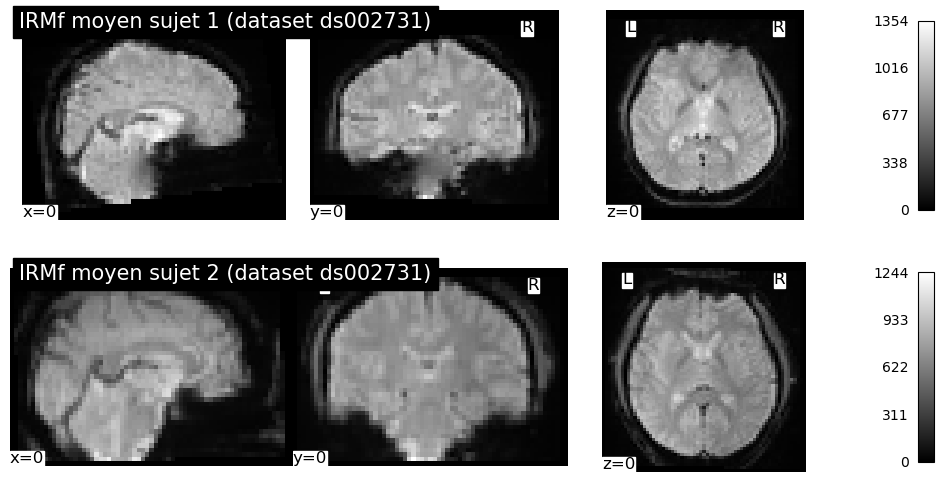

In [12]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6))

mean_img_result1 = mean_img(fmri_imgs1, copy_header=True)
mean_img_result2 = mean_img(fmri_imgs2, copy_header=True)

plot_img(mean_img_result1, colorbar=True, cbar_tick_format="%i", cmap="gray", axes=axes[0], title=("IRMf moyen sujet 1 (dataset ds002731)"), cut_coords=coordonnees, draw_cross=False)
plot_img(mean_img_result2, colorbar=True, cbar_tick_format="%i", cmap="gray", axes=axes[1], title=("IRMf moyen sujet 2 (dataset ds002731)"), cut_coords=coordonnees, draw_cross=False)

plt.show()

## 2.3 Display the events files (experimental paradigm)
Here, we display the first five rows of each event file (.tsv) for each run (n = 9) to keep the output relatively short. These files provide valuable information on the characteristics of the task and the participants' behavioural responses (i.e. define the timing of the stimulation (word presentation), type of experimental condition (rep1, 2, 3), etc.). 

In [19]:
events_files_df = pd.read_csv(events_files[0], sep='\t')
events_files_df.head(10)

,onset,duration,trial_type,response,response_time,stim_group,stim_id,trial_id,run_id,stim_type
0,2.006,3,0.0,NaN,NaN,NaN,110,1,1,NaN
1,8.005,3,rep1,very pleasant,0.687,3.0,134,2,1,encoding
2,20.021,3,rep1,little pleasant,0.993,3.0,133,3,1,encoding
3,32.020,3,rep1,very pleasant,0.866,3.0,137,4,1,encoding
4,44.018,3,rep1,NaN,NaN,3.0,132,5,1,encoding
5,56.017,3,rep1,very pleasant,1.477,3.0,136,6,1,encoding
6,68.016,3,rep1,very pleasant,1.277,3.0,138,7,1,encoding
7,80.015,3,rep1,little pleasant,1.190,3.0,131,8,1,encoding
8,92.013,3,rep1,very pleasant,0.920,3.0,135,9,1,encoding
9,104.012,3,0.0,NaN,NaN,NaN,400,10,1,NaN


In [20]:
events = [pd.read_csv(f, sep='\t')[['onset', 'duration', 'trial_type']] for f in events_files]

In [21]:
for i, df in enumerate(events):
    print(f"Run {i+1}")
    display(df.head())

Run 1


,onset,duration,trial_type
0,2.006,3,0.0
1,8.005,3,rep1
2,20.021,3,rep1
3,32.020,3,rep1
4,44.018,3,rep1


Run 2


,onset,duration,trial_type
0,2.012,3,0.0
1,8.011,3,rep1
2,20.027,3,rep1
3,32.009,3,rep1
4,44.025,3,rep1


Run 3


...

,onset,duration,trial_type
0,2.009,3,0.0
1,8.025,3,rep1
2,20.007,3,rep1
3,32.006,3,rep1
4,44.005,3,rep1


Run 8


,onset,duration,trial_type
0,2.007,3,0.0
1,8.007,3,rep1
2,20.022,3,rep1
3,32.004,3,rep1
4,44.020,3,rep1


Run 9


,onset,duration,trial_type
0,2.020,3,0.0
1,8.019,3,rep1
2,20.018,3,rep1
3,32.017,3,rep1
4,44.032,3,rep1


### 2.3 Tâche 2-B (nouveau dataset)

Dans le dataset 2, les fichiers d'événements ne contiennent pas de colonne « trial_type » car tous les trials d'un même sujet appartiennent à la même condition expérimentale. Chaque participant a une seule condition (auditory-auditory, auditory-visual ou visual-visual) au lieu d'avoir 3 répétitions de la même tâche (rep1, rep2 et rep3). La condition de chaque sujet est récupérée à partir du fichier « participants.tsv » qui se retrouve dans le dataset.

> **À NOTER :**
> N'hésitez pas à passer à la section « Step 3: Define and fit the GLM, 3.1 Apply a mask »

In [13]:
lien_participants_tsv = f"{dataset_dir}/participants.tsv"
participants_tsv = sorted(glob.glob(lien_participants_tsv))
participants_tsv

['/home/atyanna/projet3019/ds002731/participants.tsv']

In [14]:
events1 = [pd.read_csv(f, sep='\t')[['onset', 'duration']] for f in events_files1]
events2 = [pd.read_csv(f, sep='\t')[['onset', 'duration']] for f in events_files2] 
participant_trial_type = pd.read_csv(participants_tsv[0], sep='\t')[['participant_id', 'group']] 
participant_trial_type



,participant_id,group
0,3176,audio-visual
1,3201,audio-visual
2,3256,audio-visual
3,3257,audio-visual
4,3272,audio-visual
...,...,...
62,5035,visual-visual
63,5036,visual-visual
64,5037,visual-visual
65,5039,visual-visual


In [15]:
group1 = participant_trial_type[participant_trial_type["participant_id"] == int(subj1)]["group"].values[0]
group2 = participant_trial_type[participant_trial_type["participant_id"] == int(subj2)]["group"].values[0]

print(f"Sujet 1 ({subj1}), groupe {group1}")
for i, df in enumerate(events1):
    print(f"Run {i+1}")
    display(df.head())

print(f"Sujet 2 ({subj2}), groupe {group2}")
for i, df in enumerate(events2):
    print(f"Run {i+1}")
    display(df.head())

Sujet 1 (5024), groupe visual-visual
Run 1


,onset,duration
0,8.124519,1
1,20.038557,1
2,32.019580,1
3,44.034101,1
4,56.031782,1


Run 2


,onset,duration
0,8.033808,1
1,20.031435,1
2,32.029171,1
3,44.027017,1
4,56.024714,1


Run 3


...

,onset,duration
0,8.031900,1
1,20.029235,1
2,32.026645,1
3,44.023909,1
4,56.021258,1


Run 2


,onset,duration
0,8.019991,1
1,20.034116,1
2,32.031369,1
3,44.028711,1
4,56.026193,1


Run 3


,onset,duration
0,8.030573,1
1,20.011249,1
2,32.025290,1
3,44.022639,1
4,56.019970,1


# Step 3: Define and fit the GLM

## 3.1 Apply a mask
This mask helps define which voxels in the brain should be included in the analysis. The voxels that fall outside of the region defined by the mask will be excluded from model fitting. For example, when we extracted activation maps prior to setting the mask, we saw what appeared to be a lot of activation in the two eyes. With the mask, these no longer figure in the outputs.


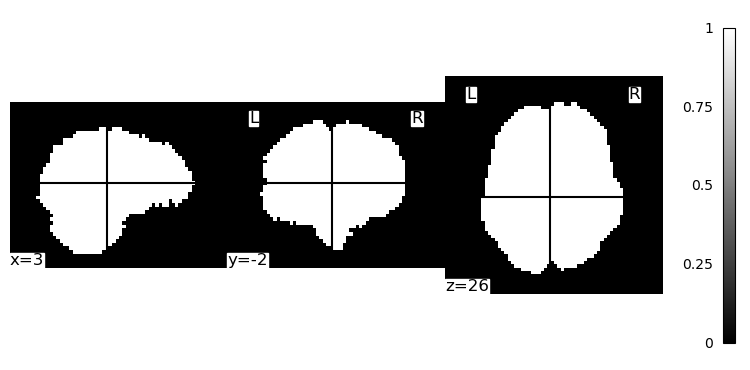

In [22]:
mask = masking.compute_epi_mask(mean_img_result)
plot_img(mask)

### 3.1 Tâche 2-B (nouveau dataset)

Les masques cérébraux sont calculés automatiquement à partir de l'image IRMf moyenne de chaque sujet. Les deux masques sont affichés aux mêmes coordonnées pour permettre une comparaison visuelle intuitive. Les petites différences de forme entre les deux masques sont normales et reflètent les différences anatomiques entre les sujets.

> **À NOTER :**
> N'hésitez pas à passer à la section « 3.2 Define and apply the General Linear Model (GLM) »

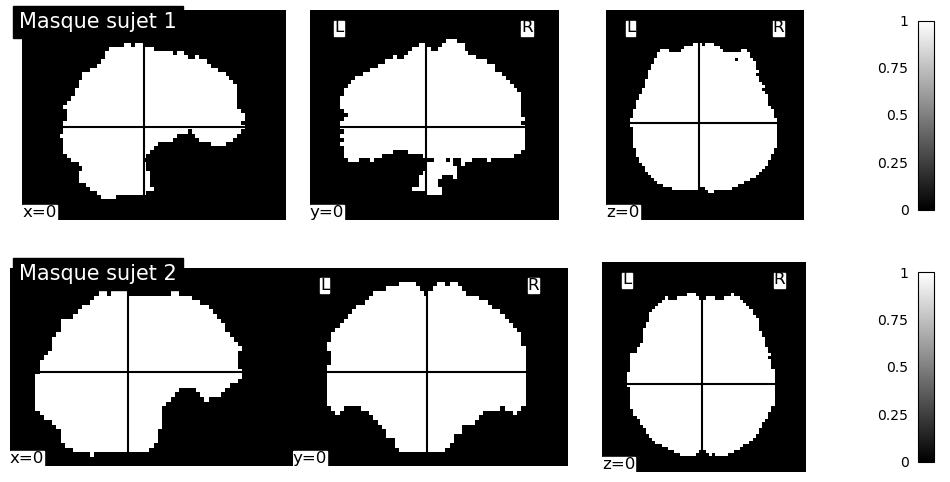

In [16]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6))

mask1 = masking.compute_epi_mask(mean_img_result1)
mask2 = masking.compute_epi_mask(mean_img_result2)

plot_img(mask1, axes=axes[0], title=("Masque sujet 1"), cut_coords=coordonnees)
plot_img(mask2, axes=axes[1], title=("Masque sujet 2"), cut_coords=coordonnees)

plt.show()


## 3.2 Define and apply the General Linear Model (GLM)
The GLM is a commonly used statistical framework in fMRI analyses to model the relationship between the observed blood-oxygen-level-dependent (BOLD) signal (outcome) and exploratory variables, which include task conditions from the design matrix, parameter estimates, and residuals (noise). We use the GLM to model expected brain responses during different phases of a task, estimate how well the observed data fits the model, compute contrasts, and visualize various brain activation maps. 

In [23]:
first_level_model = FirstLevelModel(
    t_r=2,
    noise_model="ar1",
    standardize=False,
    mask_img=mask,
    hrf_model="spm",
    drift_model="cosine",
    high_pass=0.01,
    signal_scaling=False,
    minimize_memory=False,
)

Now that we have specified the model, we can run it on the "preprocessed" fMRI images. 

In [24]:
first_level_model = first_level_model.fit(smoothed_imgs, events=events)

### 3.2 Tâche 2-B (nouveau dataset)

Un GLM est appliqué aux deux sujets du dataset 2 en utilisant le masque cérébral respectif. Les paramètres du modèle sont identiques à ceux utilisés pour le dataset original.

> **À NOTER :**
> N'hésitez pas à passer à la section « 3.3 View the design matrix »

In [17]:

first_level_model1 = FirstLevelModel(
    t_r=2,
    noise_model="ar1",
    standardize=False,
    mask_img=mask1,
    hrf_model="spm",
    drift_model="cosine",
    high_pass=0.01,
    signal_scaling=False,
    minimize_memory=False,
    )

first_level_model2 = FirstLevelModel(
    t_r=2,
    noise_model="ar1",
    standardize=False,
    mask_img=mask2,
    hrf_model="spm",
    drift_model="cosine",
    high_pass=0.01,
    signal_scaling=False,
    minimize_memory=False,
    )

In [ ]:
first_level_model1 = first_level_model1.fit(smoothed_imgs1, events=events1)
first_level_model2 = first_level_model2.fit(smoothed_imgs2, events=events2)

## 3.3 View the design matrix
The design matrix shows us the different phases of the task during each run. For example, each rep column shows the list which was showed three times rep1, rep2, rep3). It gives us the expected activation based on the model. For example, we can also see the eight blocs per rep which represent the eight words that were shown in each list. Row represents time, and columns contain the predictors (experimental conditions). we also have columns that represent low-frequency signals (drift) and a constant regressor. Here, we see the design matrix for the first run. However, these are identical for all nine runs since each run represents a word list of the same format.

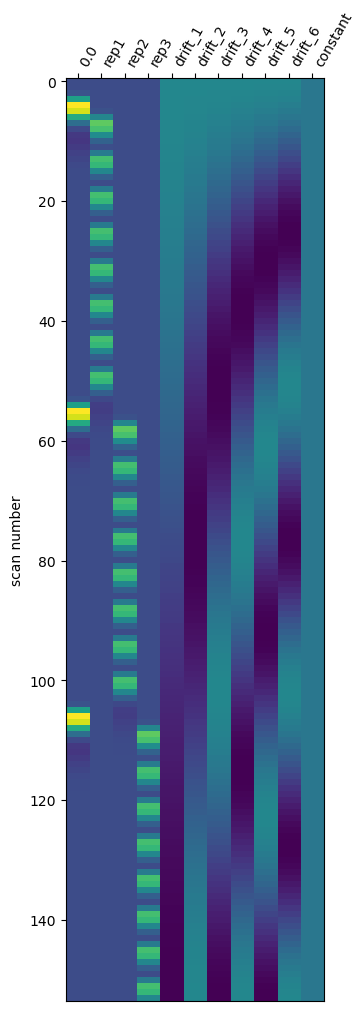

In [25]:
design_matrix = first_level_model.design_matrices_[0]
plot_design_matrix(design_matrix)
show()

### 3.3 Tâche 2-B (nouveau dataset)

Puisque le dataset 2 ne contient qu'une seule condition expérimentale par sujet (« dummy »), la *design matrix* est plus simple que celle du dataset original (elle ne contient pas de colonnes rep1/rep2/rep3). La tâche expérimentale est identique pour les deux sujets, donc une seule *design matrix* est affichée.


> **À NOTER :**
> N'hésitez pas à passer à la section « Step 4: Define and compute contrasts, 4.1 Define contrasts »

In [ ]:
design_matrix1 = first_level_model1.design_matrices_[0]

plot_design_matrix(design_matrix1)
plt.show()

## 3.4 View the expected fMRI signal
Another way to view the design matrix is by plotting the expected hemodynamic response on a graph. Here is another way to plot the expected response on a graph. Here, each color represents a rep, and there are 8 peaks/rep, showcasing the expected hemodynamic response for each peak when seeing the word. Each color represents a column of the above design matrix.

In [ ]:
plt.plot(design_matrix["rep1"], label="rep1", color="red")
plt.plot(design_matrix["rep2"], label="rep2", color="blue")
plt.plot(design_matrix["rep3"], label="rep3", color="orange")

plt.xlabel("Time (s)")
plt.ylabel("Amplitude of BOLD signal")
plt.title("Expected Signal")
plt.legend()

show()

 
> **Note** : La tâche 2-B (dataset) n'est pas applicable à cette section puisqu'il n'y a pas de conditions de répétition (rep1/rep2/rep3) dans ce dataset.

# Step 4: Define and compute contrasts
To get more interesting results out of the GLM model, we can compute contrasts between regressors of interest. A contrast associates some columns of the model, seen in the design matrix, with statistics. So, a contrast considers the effects of stimulation. Here, we will look at the contrast between rep1 (Time 1) and rep3 (Time 3), meaning that we would expect to see decreased activation for rep3 vs rep1 because it has already been previously shown and encoded by the participant. The regressors in the design matrix represent conditions we can use to generate the contrasts. 

## 4.1 Define contrasts

In [ ]:
regressors = first_level_model.design_matrices_[0].columns
print(regressors)

Index(['0.0', 'rep1', 'rep2', 'rep3', 'drift_1', 'drift_2', 'drift_3',
       'drift_4', 'drift_5', 'drift_6', 'constant'],
      dtype='str')


A way to define contrasts is to assign values of -1, 0, 1 to each regressor. Here, since we are interested in the contrast when we substract rep3 from rep1, we assign -1 to rep3 and 1 to rep1. 

In [28]:
# Define contrast: rep1 (1), rep3 (-1), others (0)
contrast0 = np.array([0, 1, 0, -1, 0, 0, 0, 0, 0, 0, 0])

### 4.1 Tâche 2-B (nouveau dataset)

Pour le dataset 2, le contraste utilisé est **dummy vs baseline** (voir 3.3 Tâche 2-B), donc l'activation de la tâche d'encodage par rapport au repos. Il n'est pas possible de comparer les deux participants ensemble avec cette technique de contraste, donc la meilleure réplication du dataset original (contraste rep1 vs rep3) était de les comparer à leur état de repos.

La décision de garder les deux participants dans le notebook malgré l'impossibilité de les comparer était pour montrer l'effort de tout ce qui avait déjà été fait, mais aussi parce que c'est des variables qui seraient intéressantes à comparer éventuellement (puisque que c'est le but de l'article de ce nouveau dataset).


> **À NOTER :**
> N'hésitez pas à passer à la section « 4.2 Compute contrasts and generate maps »

In [19]:
#SUJET 1
regressors1 = first_level_model1.design_matrices_[0].columns
print(regressors1)

#SUJET 2
regressors2 = first_level_model2.design_matrices_[0].columns
print(regressors2)

Index(['dummy', 'drift_1', 'drift_2', 'drift_3', 'drift_4', 'drift_5',
       'drift_6', 'constant'],
      dtype='str')
Index(['dummy', 'drift_1', 'drift_2', 'drift_3', 'drift_4', 'drift_5',
       'drift_6', 'constant'],
      dtype='str')


In [20]:
# Define contrast: dummy (1), others (0)
contrast = np.array([1, 0, 0, 0, 0, 0, 0, 0])

## 4.2 Compute contrasts and generate maps
Here, beta maps are generated to show the actual estimated effect size (i.e., how much each voxel's signal is explained by the contrast). The z-map represents the results of a statistical test on the beta. Finally, thresholded maps below are used to show voxels surviving multiple voxel comparisons. 

We use the subject's anatomical image as a background to these maps. 


/tmp/ipykernel_23057/1157522711.py:1: RuntimeWarning: The same contrast will be used for all 9 runs. If the design matrices are not the same for all runs, (for example with different column names or column order across runs) you should pass contrast as an expression using the name of the conditions as they appear in the design matrices.
  beta_map = first_level_model.compute_contrast(contrast0, output_type="effect_size")
/tmp/ipykernel_23057/1157522711.py:2: UserWarning: kwargs['alpha']=0.9 detected in parameters.
Overriding with transparency=None.
To suppress this warning pass your 'alpha' value via the 'transparency' parameter.
  plot_stat_map(beta_map,


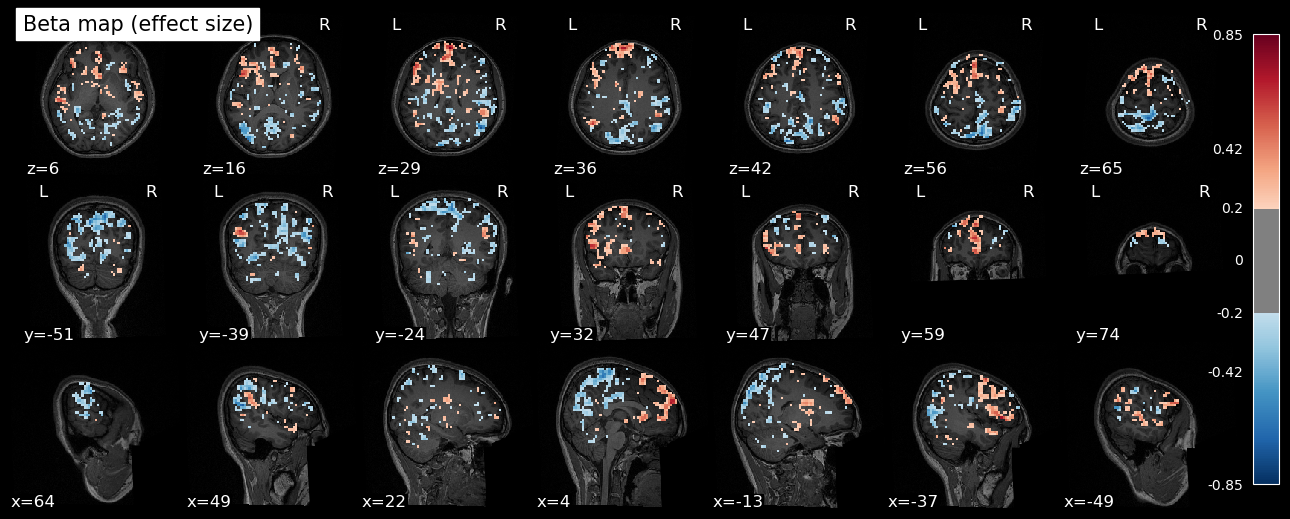

In [29]:
beta_map = first_level_model.compute_contrast(contrast0, output_type="effect_size")
plot_stat_map(beta_map, 
              #bg_img=mean_img_result,
              bg_img=anat_img,
              title="Beta map (effect size)", 
              display_mode='mosaic', 
              threshold=0.2,
              alpha=0.9,
              black_bg=True,
             )

/tmp/ipykernel_23057/1837586071.py:1: RuntimeWarning: The same contrast will be used for all 9 runs. If the design matrices are not the same for all runs, (for example with different column names or column order across runs) you should pass contrast as an expression using the name of the conditions as they appear in the design matrices.
  z_map = first_level_model.compute_contrast(contrast0, output_type='z_score')


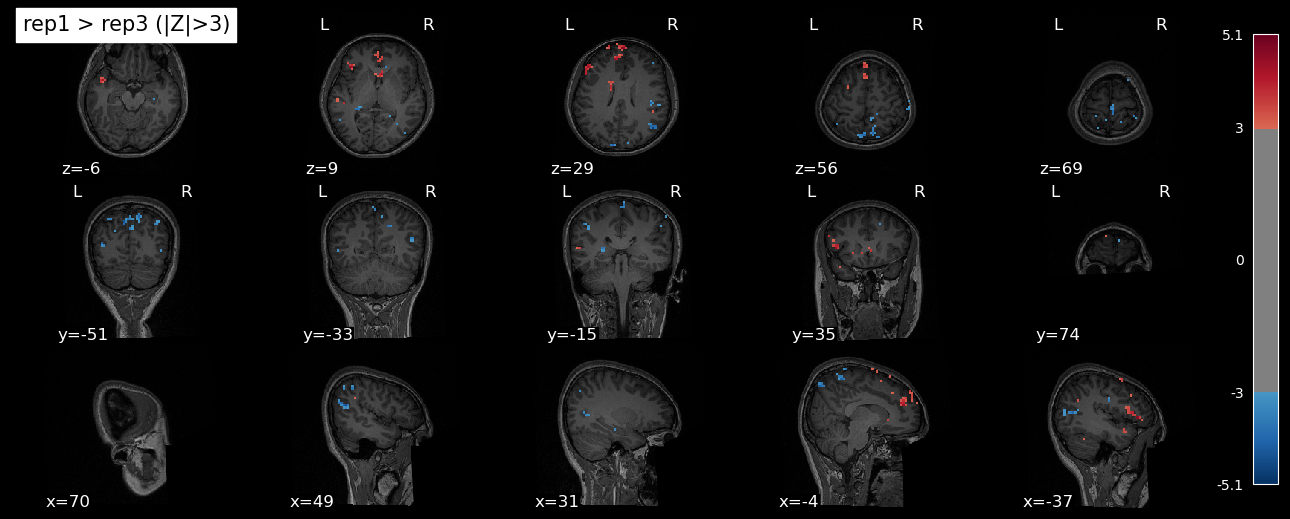

In [30]:
z_map = first_level_model.compute_contrast(contrast0, output_type='z_score')
plot_stat_map(z_map,
              #bg_img=mean_img_result,
              bg_img=anat_img,
              threshold=3,
              display_mode='mosaic',
              cut_coords=5,
              title='rep1 > rep3 (|Z|>3)', 
              black_bg=True,)

Here's a variation on the z_map by playing with the different parameters and coordinates

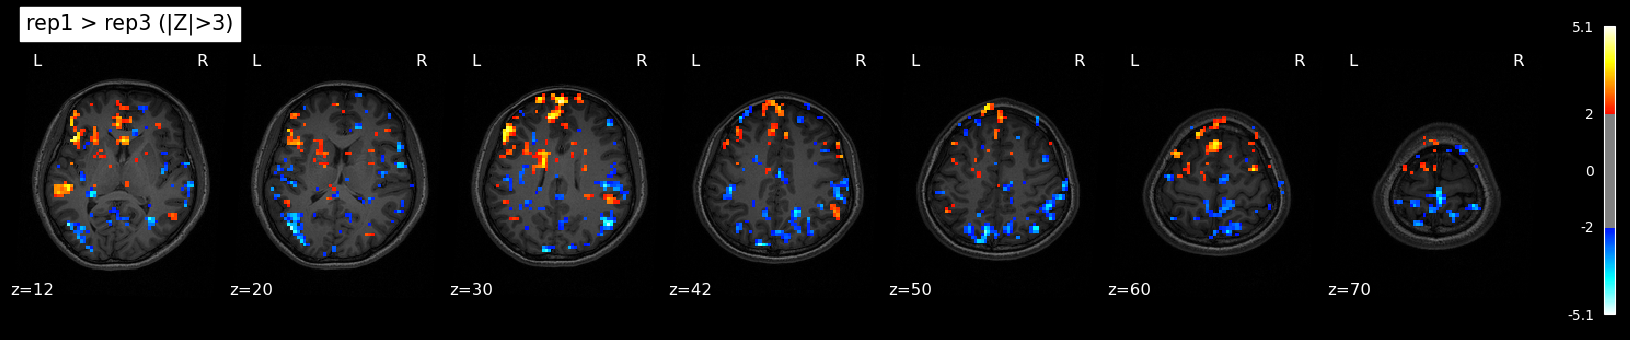

In [31]:
cut_coords = [12, 20, 30, 42, 50, 60, 70]  # chose these coordinates based on the clusters table below

plot_stat_map(
    z_map,
    bg_img=anat_img,              
    threshold=2,                   
    display_mode='z',             
    cut_coords=cut_coords,        
    cmap='cold_hot',              
    black_bg=True,
    title='rep1 > rep3 (|Z|>3)',
    annotate=True,                
)

### 4.2 Tâche 2-B (nouveau dataset)

Cartes d'activation des deux sujets.

> **À NOTER :**
> N'hésitez pas à passer à la section « Step 5: Observed and predicted time series »

/tmp/ipykernel_1271/3997657479.py:2: RuntimeWarning: The same contrast will be used for all 3 runs. If the design matrices are not the same for all runs, (for example with different column names or column order across runs) you should pass contrast as an expression using the name of the conditions as they appear in the design matrices.
  beta_map1 = first_level_model1.compute_contrast(contrast, output_type="effect_size")
/tmp/ipykernel_1271/3997657479.py:3: UserWarning: kwargs['alpha']=0.9 detected in parameters.
Overriding with transparency=None.
To suppress this warning pass your 'alpha' value via the 'transparency' parameter.
  plot_stat_map(beta_map1,
/tmp/ipykernel_1271/3997657479.py:16: UserWarning: kwargs['alpha']=0.9 detected in parameters.
Overriding with transparency=None.
To suppress this warning pass your 'alpha' value via the 'transparency' parameter.
  plot_stat_map(beta_map2,


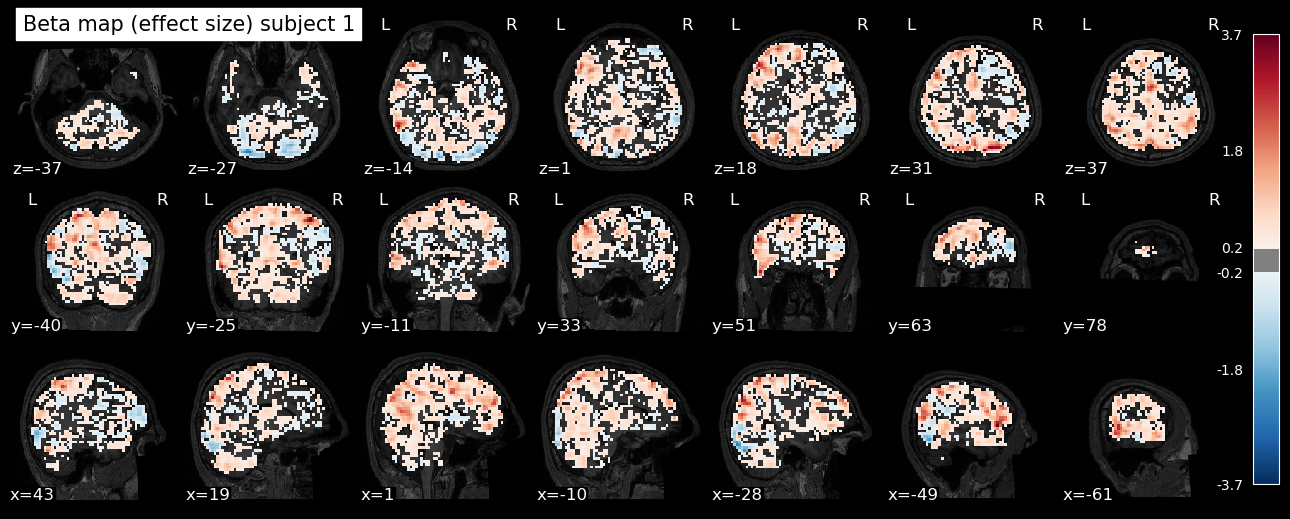

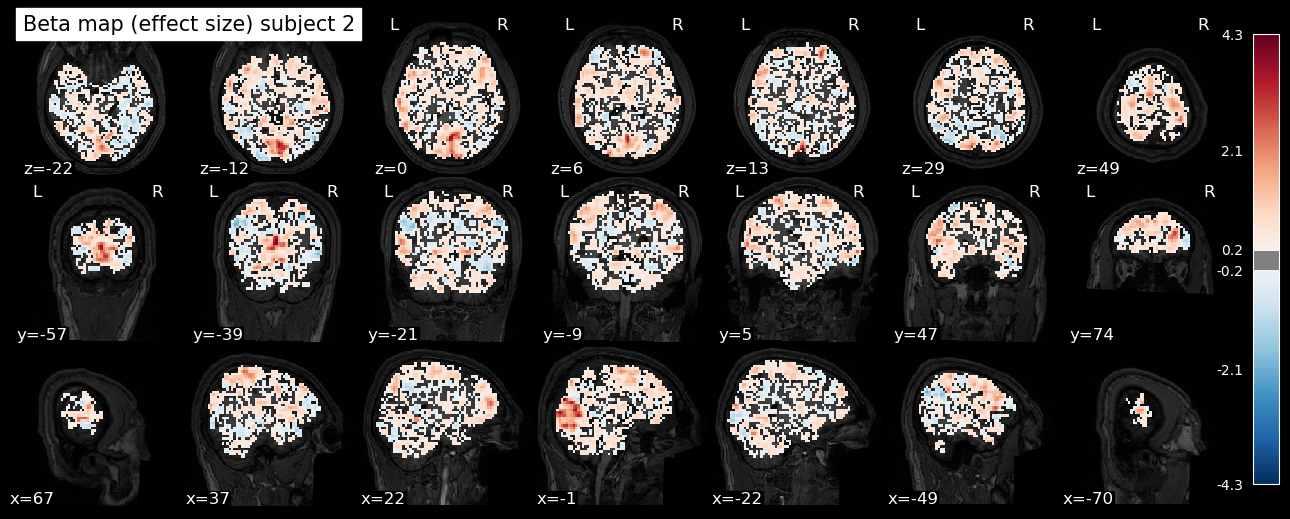

In [21]:
#SUJET 1
beta_map1 = first_level_model1.compute_contrast(contrast, output_type="effect_size")
plot_stat_map(beta_map1, 
              #bg_img=mean_img_result,
              bg_img=anat_img1,
              title="Beta map (effect size) subject 1", 
              display_mode='mosaic', 
              threshold=0.2,
              alpha=0.9,
              black_bg=True,
             )


#SUJET 2
beta_map2 = first_level_model2.compute_contrast(contrast, output_type="effect_size")
plot_stat_map(beta_map2, 
              #bg_img=mean_img_result,
              bg_img=anat_img2,
              title="Beta map (effect size) subject 2", 
              display_mode='mosaic', 
              threshold=0.2,
              alpha=0.9,
              black_bg=True,
             )


/tmp/ipykernel_1271/2844544930.py:2: RuntimeWarning: The same contrast will be used for all 3 runs. If the design matrices are not the same for all runs, (for example with different column names or column order across runs) you should pass contrast as an expression using the name of the conditions as they appear in the design matrices.
  z_map1 = first_level_model1.compute_contrast(contrast, output_type='z_score')


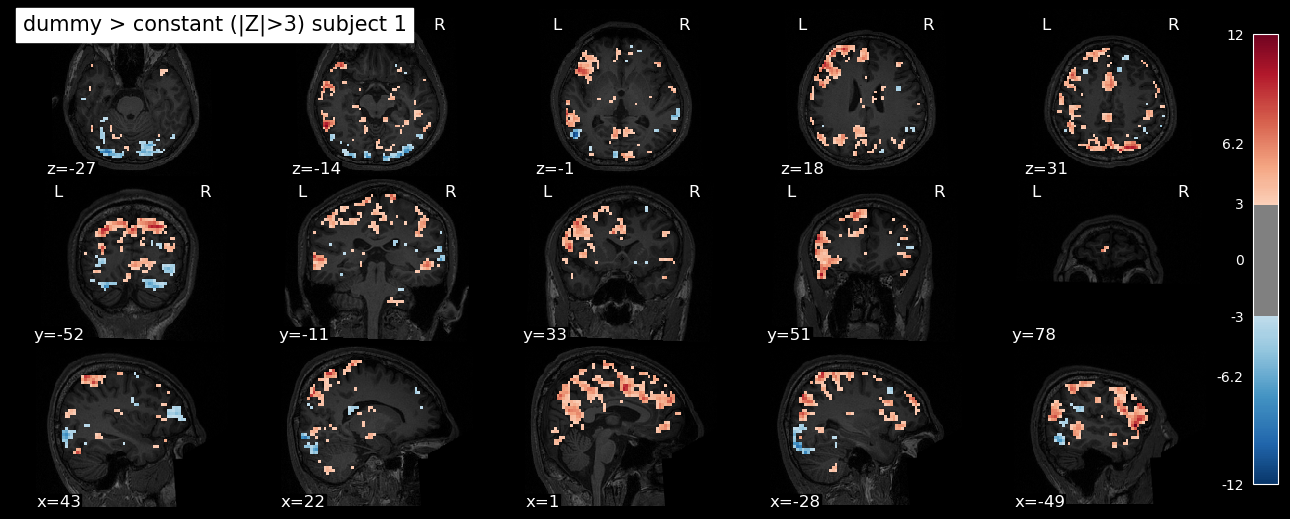

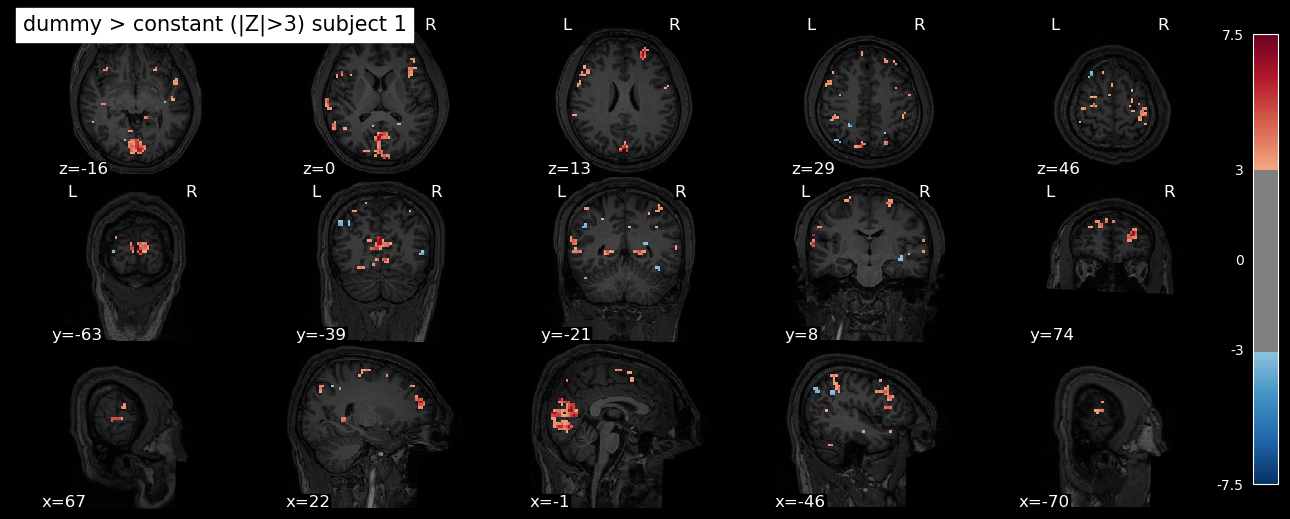

In [22]:
#SUJET 1
z_map1 = first_level_model1.compute_contrast(contrast, output_type='z_score')
plot_stat_map(z_map1,
              #bg_img=mean_img_result,
              bg_img=anat_img1,
              threshold=3,
              display_mode='mosaic',
              cut_coords=5,
              title='dummy > constant (|Z|>3) subject 1', 
              black_bg=True,)

#SUJET 2
z_map2 = first_level_model2.compute_contrast(contrast, output_type='z_score')
plot_stat_map(z_map2,
              #bg_img=mean_img_result,
              bg_img=anat_img2,
              threshold=3,
              display_mode='mosaic',
              cut_coords=5,
              title='dummy > constant (|Z|>3) subject 1', 
              black_bg=True,)

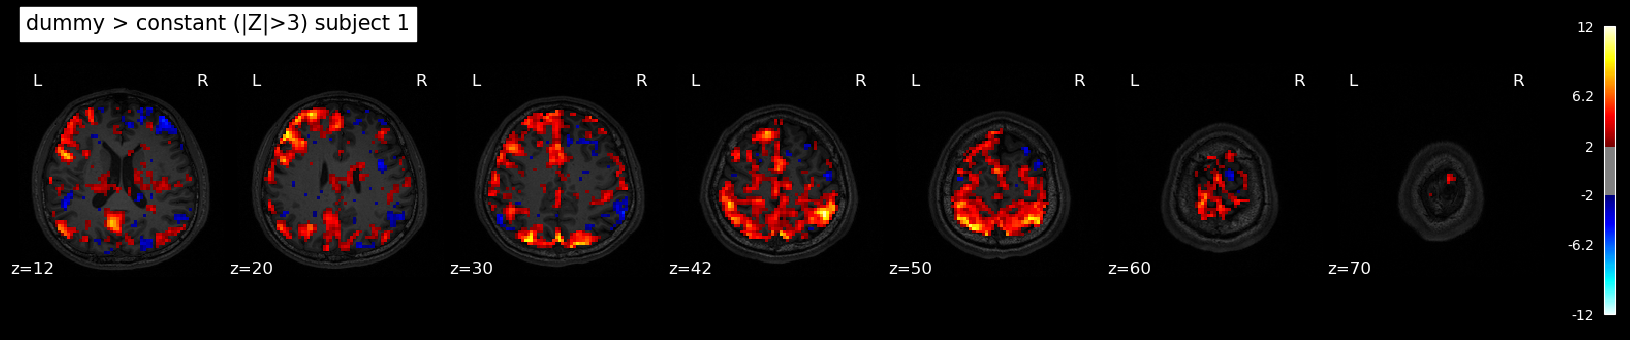

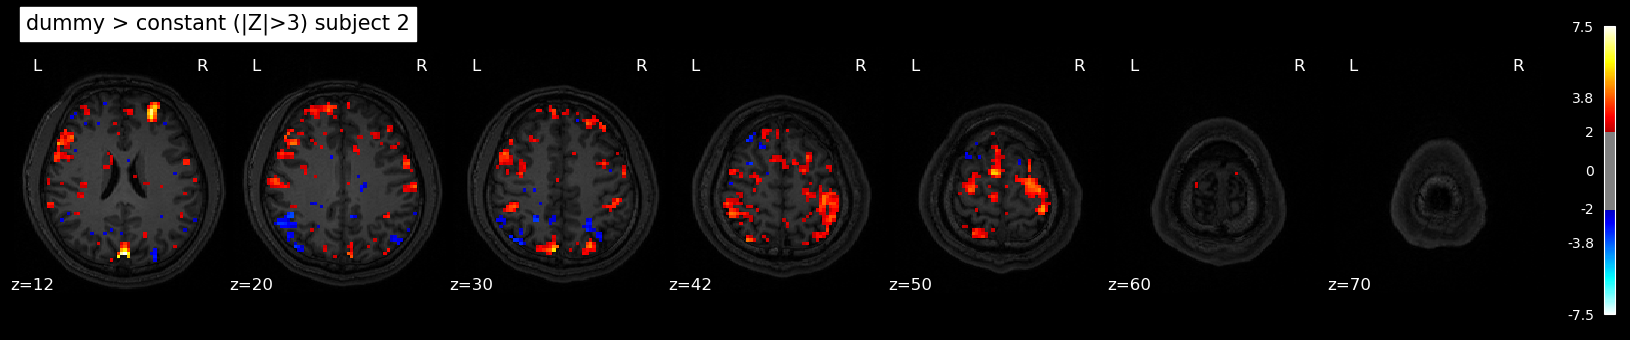

In [23]:
cut_coords = [12, 20, 30, 42, 50, 60, 70]  # chose these coordinates based on the clusters table below

#SUJET 1
plot_stat_map(
    z_map1,
    bg_img=anat_img1,              
    threshold=2,                   
    display_mode='z',             
    cut_coords=cut_coords,        
    cmap='cold_hot',              
    black_bg=True,
    title='dummy > constant (|Z|>3) subject 1',
    annotate=True,                
)

#SUJET 2
plot_stat_map(
    z_map2,
    bg_img=anat_img2,              
    threshold=2,                   
    display_mode='z',             
    cut_coords=cut_coords,        
    cmap='cold_hot',              
    black_bg=True,
    title='dummy > constant (|Z|>3) subject 2',
    annotate=True,                
)

# Step 5: Observed and predicted time series
A way to assess the quality of the fit of the newly defined GLM is to compare the observed and predicted time series of voxels. It is used to validate if the model captures actual signal. Here, to do so, we select the top three clusters.

In [32]:
z_map = first_level_model.compute_contrast('rep1 - rep3')
table = get_clusters_table(z_map, stat_threshold=2,
                           cluster_threshold=20).set_index('Cluster ID', drop=True)
table

/tmp/ipykernel_23057/3609742554.py:1: RuntimeWarning: The same contrast will be used for all 9 runs. If the design matrices are not the same for all runs, (for example with different column names or column order across runs) you should pass contrast as an expression using the name of the conditions as they appear in the design matrices.
  z_map = first_level_model.compute_contrast('rep1 - rep3')


,X,Y,Z,Peak Stat,Cluster Size (mm3)
Cluster ID,,,,,
1,-39.224443,25.440192,-8.069926,4.972231,1455
1a,-30.231076,34.422652,-7.410550,3.333714,
1b,-32.975506,40.653183,-13.907365,3.228184,
2,-40.111201,33.629125,15.313082,4.930794,12800
2a,-36.860053,42.849791,9.151153,4.425354,
2b,-46.613498,42.171347,28.579227,4.337215,
2c,-13.637820,15.143585,28.902967,3.988936,
3,1.224443,71.973684,34.763263,4.913865,10513
3a,-4.517775,57.221027,27.418466,4.296670,


In [33]:
table_reset = table.reset_index(drop=False)
coords = table_reset.iloc[0:3][['X', 'Y', 'Z']].values

In [34]:
masker = input_data.NiftiSpheresMasker(coords)
real_timeseries = [
    masker.fit_transform(run_img)
    for run_img in smoothed_imgs
]
real_timeseries = np.vstack(real_timeseries)

predicted_timeseries = [
    masker.transform(pred_img)
    for pred_img in first_level_model.predicted
]
predicted_timeseries = np.vstack(predicted_timeseries)

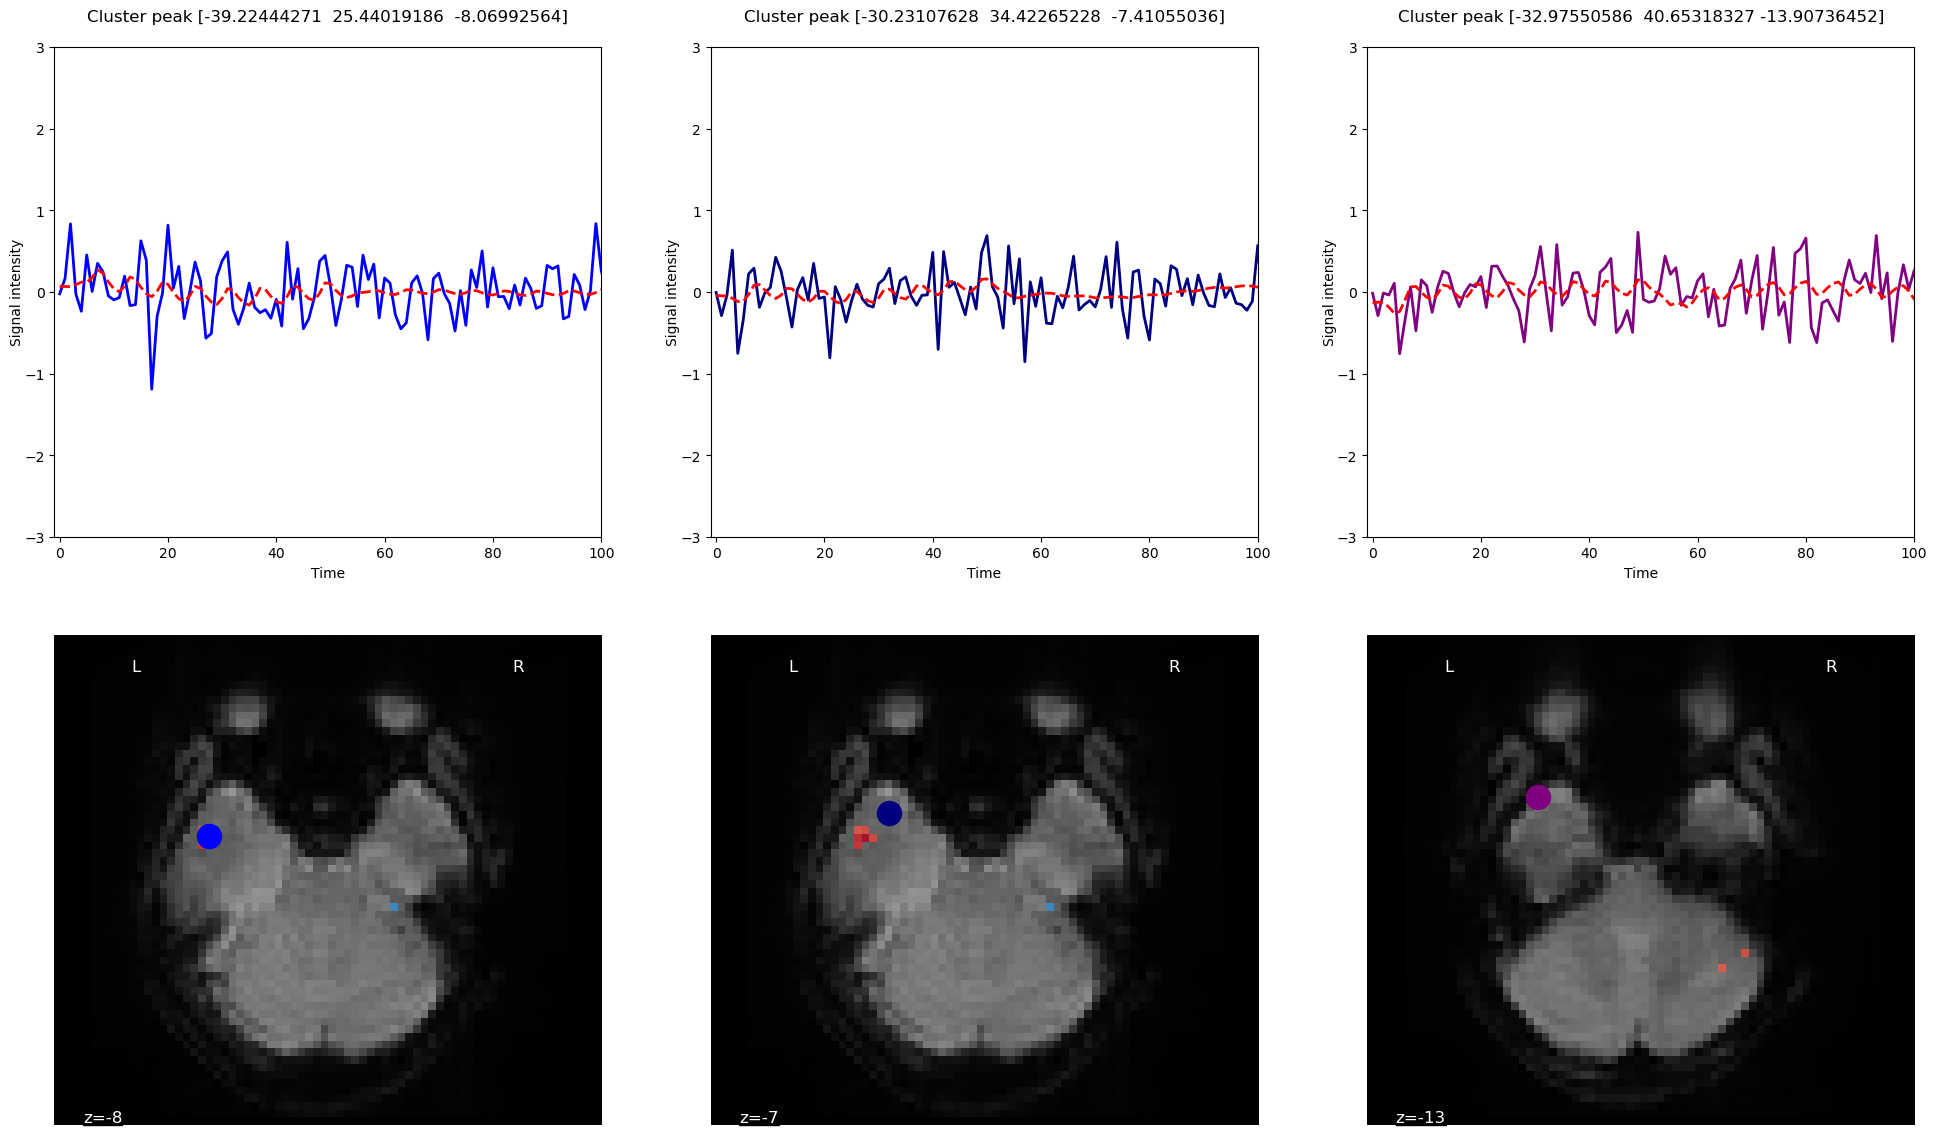

In [35]:
colors = ['blue', 'navy', 'purple', 'magenta', 'olive', 'teal']
# plot the time series and corresponding locations
from nilearn import plotting
fig1, axs1 = plt.subplots(2, 3)
for i in range(0, 3):
    # plotting time series
    axs1[0, i].set_title('Cluster peak {}\n'.format(coords[i]))
    axs1[0, i].plot(real_timeseries[:, i], c=colors[i], lw=2)
    axs1[0, i].plot(predicted_timeseries[:, i], c='r', ls='--', lw=2)
    axs1[0, i].set_xlabel('Time')
    axs1[0, i].set_xlim(-1, 100)
    axs1[0, i].set_ylabel('Signal intensity', labelpad=0)
    axs1[0, i].set_ylim(-3, 3)
    # plotting image below the time series
    roi_img = plotting.plot_stat_map(
        z_map, cut_coords=[coords[i][2]], threshold=3.1, figure=fig1,
        axes=axs1[1, i], display_mode='z', colorbar=False, bg_img=mean_img_result)
    roi_img.add_markers([coords[i]], colors[i], 300)

fig1.set_size_inches(24, 14)

# Glue the figure
from myst_nb import glue
glue("memory-fig", fig1, display=False)

This figure shows activation maps for three activation peaks, and the signal is presented for each peak, in combination with the predicted activity of the model. The signal has been standardized, and therefore is presented here in terms of z-scores.

### Step 5: Tâche 2-B (nouveau dataset)

Pour permettre une comparaison intuitive, les mêmes coordonnées (moyenne des coordonnées des 3 clusters les plus actifs des deux sujets) sont utilisées pour les deux sujets.

> **À NOTER :**
> N'hésitez pas à passer à la section « Step 6: Further exploration and statistical testing »

In [24]:
#SUJET 1
z_map1 = first_level_model1.compute_contrast('dummy')
table1 = get_clusters_table(z_map1, stat_threshold=2,
                           cluster_threshold=20).set_index('Cluster ID', drop=True)
table1

#SUJET 2
z_map2 = first_level_model2.compute_contrast('dummy')
table2 = get_clusters_table(z_map2, stat_threshold=2,
                           cluster_threshold=20).set_index('Cluster ID', drop=True)


/tmp/ipykernel_1271/1841318907.py:2: RuntimeWarning: The same contrast will be used for all 3 runs. If the design matrices are not the same for all runs, (for example with different column names or column order across runs) you should pass contrast as an expression using the name of the conditions as they appear in the design matrices.
  z_map1 = first_level_model1.compute_contrast('dummy')


In [25]:
#SUJET 1
table_reset1 = table1.reset_index(drop=False)
coords1 = table_reset1.iloc[0:3][['X', 'Y', 'Z']].values

#SUJET 2
table_reset2 = table2.reset_index(drop=False)
coords2 = table_reset2.iloc[0:3][['X', 'Y', 'Z']].values

#creer des coordonnees moyennes communes pour les deux participants
coords_communes = ( (coords1 + coords2) /2 ).astype(int)

In [28]:
#Sujet 1
masker1 = input_data.NiftiSpheresMasker(coords_communes)
real_timeseries1 = [
    masker1.fit_transform(run_img)
    for run_img in smoothed_imgs1
]
real_timeseries1 = np.vstack(real_timeseries1)

predicted_timeseries1 = [
    masker1.transform(pred_img)
    for pred_img in first_level_model1.predicted
]
predicted_timeseries1 = np.vstack(predicted_timeseries1)

#Sujet 2
masker2 = input_data.NiftiSpheresMasker(coords_communes)
real_timeseries2 = [
    masker2.fit_transform(run_img)
    for run_img in smoothed_imgs2
]
real_timeseries2 = np.vstack(real_timeseries2)

predicted_timeseries2 = [
    masker2.transform(pred_img)
    for pred_img in first_level_model2.predicted
]
predicted_timeseries2 = np.vstack(predicted_timeseries2)

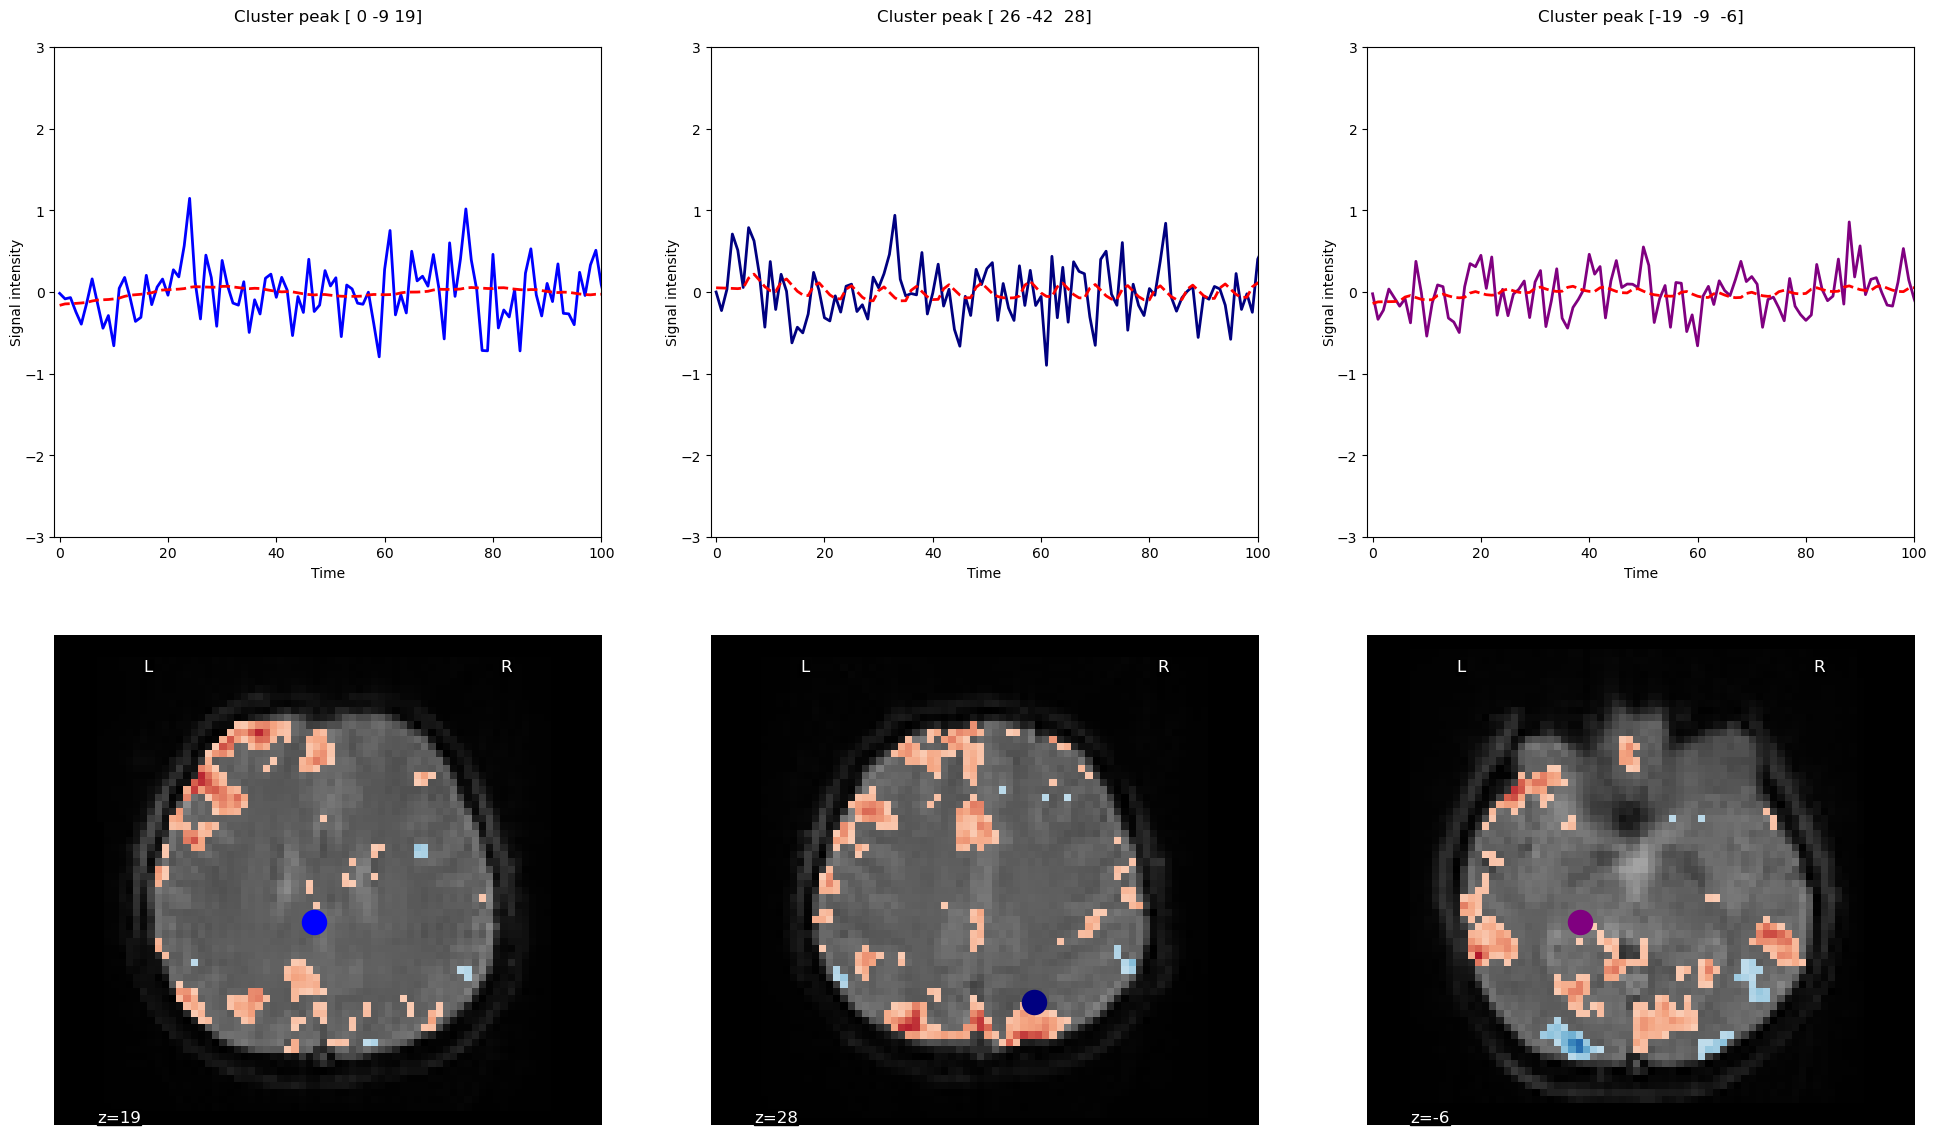

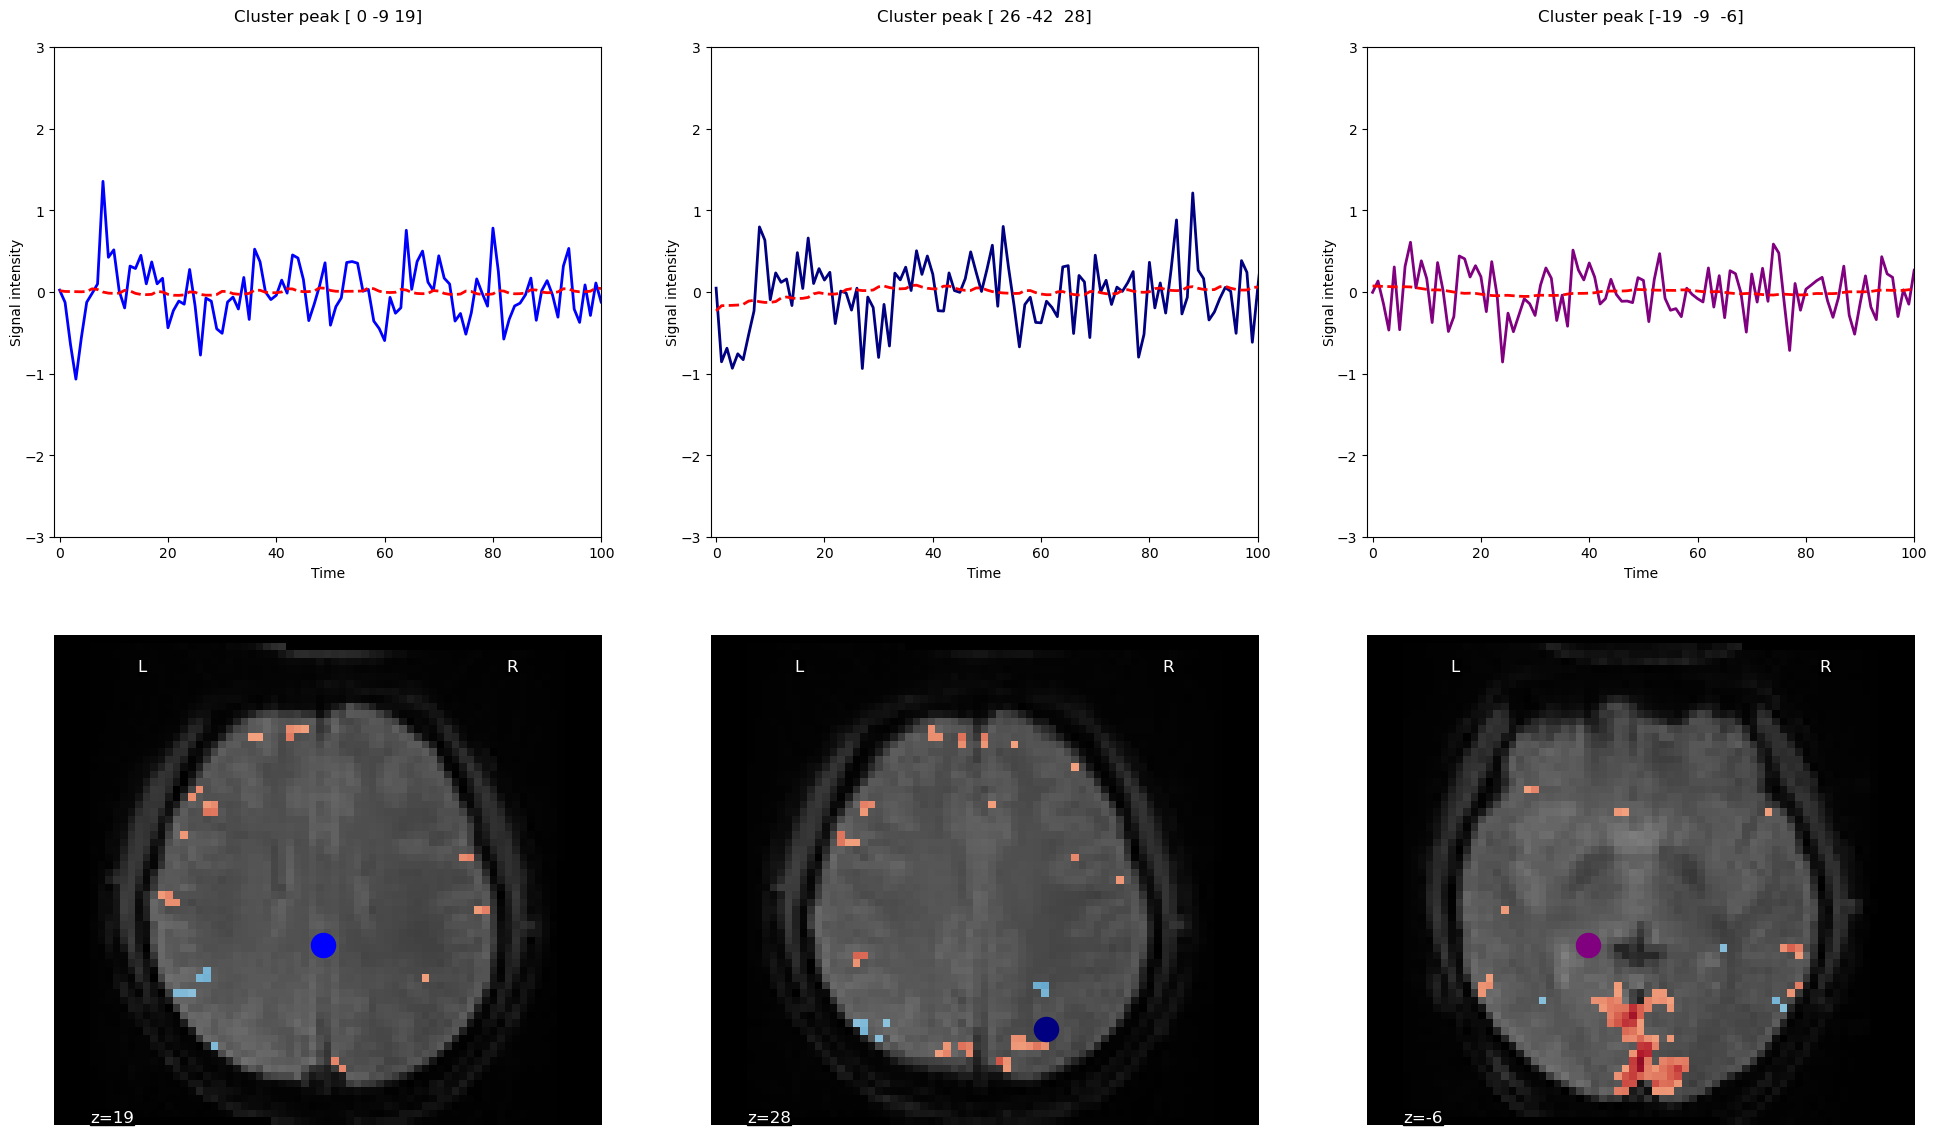

In [29]:
colors = ['blue', 'navy', 'purple', 'magenta', 'olive', 'teal']

#SUJET 1
# plot the time series and corresponding locations
from nilearn import plotting
fig1, axs1 = plt.subplots(2, 3)
for i in range(0, 3):
    # plotting time series
    axs1[0, i].set_title('Cluster peak {}\n'.format(coords_communes[i]))
    axs1[0, i].plot(real_timeseries1[:, i], c=colors[i], lw=2)
    axs1[0, i].plot(predicted_timeseries1[:, i], c='r', ls='--', lw=2)
    axs1[0, i].set_xlabel('Time')
    axs1[0, i].set_xlim(-1, 100)
    axs1[0, i].set_ylabel('Signal intensity', labelpad=0)
    axs1[0, i].set_ylim(-3, 3)
    # plotting image below the time series
    roi_img1 = plotting.plot_stat_map(
        z_map1, cut_coords=[coords_communes[i][2]], threshold=3.1, figure=fig1,
        axes=axs1[1, i], display_mode='z', colorbar=False, bg_img=mean_img_result1)
    roi_img1.add_markers([coords_communes[i]], colors[i], 300)

fig1.set_size_inches(24, 14)

# Glue the figure
from myst_nb import glue
glue("memory-fig", fig1, display=False)



#SUJET 2
# plot the time series and corresponding locations
fig1, axs1 = plt.subplots(2, 3)
for i in range(0, 3):
    # plotting time series
    axs1[0, i].set_title('Cluster peak {}\n'.format(coords_communes[i]))
    axs1[0, i].plot(real_timeseries2[:, i], c=colors[i], lw=2)
    axs1[0, i].plot(predicted_timeseries2[:, i], c='r', ls='--', lw=2)
    axs1[0, i].set_xlabel('Time')
    axs1[0, i].set_xlim(-1, 100)
    axs1[0, i].set_ylabel('Signal intensity', labelpad=0)
    axs1[0, i].set_ylim(-3, 3)
    # plotting image below the time series
    roi_img2 = plotting.plot_stat_map(
        z_map2, cut_coords=[coords_communes[i][2]], threshold=3.1, figure=fig1,
        axes=axs1[1, i], display_mode='z', colorbar=False, bg_img=mean_img_result2)
    roi_img2.add_markers([coords_communes[i]], colors[i], 300)

fig1.set_size_inches(24, 14)

# Glue the figure
glue("memory-fig", fig1, display=False)

# Step 6: Further exploration and statistical testing
## Control false positive rate
As we can see above, the visualizations show both activated voxels with Z > 3, as well as 'deactivated' voxels with Z < -3. We can show only the activate voxels.

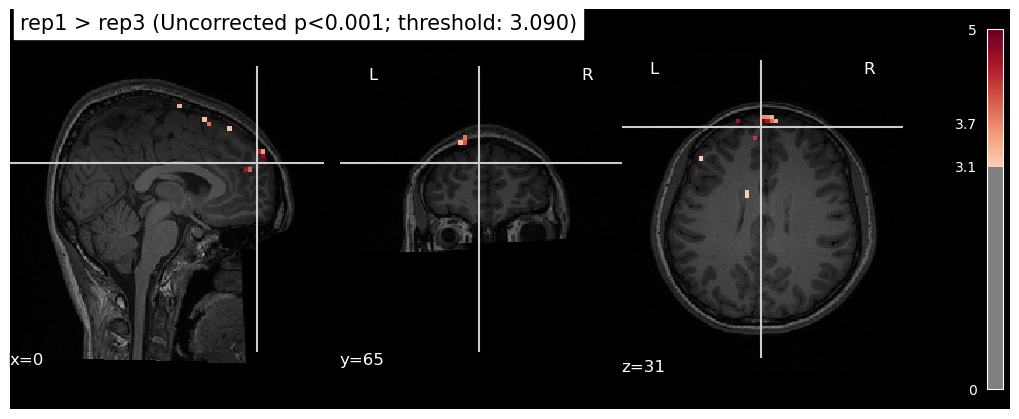

In [ ]:
clean_map, threshold = threshold_stats_img(
    z_map,
    alpha=0.001,
    height_control="fpr",
    two_sided=False)

plot_stat_map(
    clean_map,
    bg_img=anat_img,
    threshold=threshold,
    title=(
        "rep1 > rep3 (Uncorrected p<0.001; "
        f"threshold: {threshold:.3f})"
    ),
    figure=plt.figure(figsize=(10, 4))
)


## Bonferroni correction
Conservative correction - rarely used

/tmp/ipykernel_17662/4037459067.py:4: UserWarning: empty mask
  plot_stat_map(


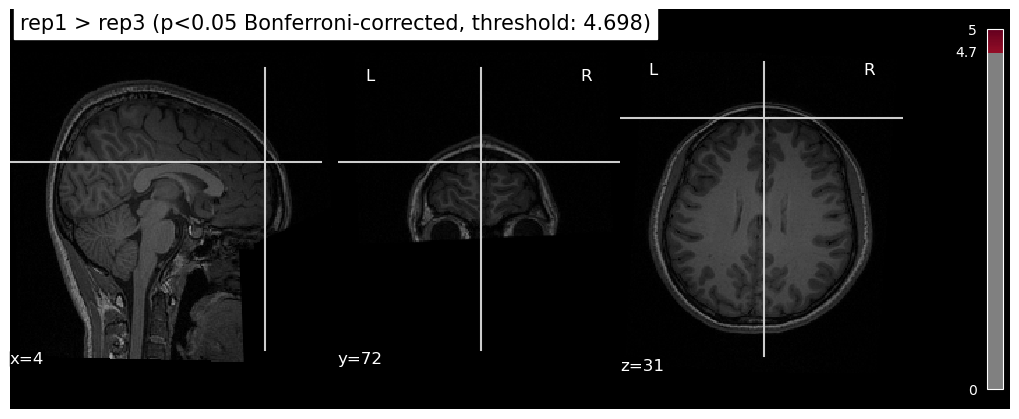

In [54]:
clean_map, threshold = threshold_stats_img(
    z_map, alpha=0.05, height_control="bonferroni", two_sided=False
)
plot_stat_map(
    clean_map,
    bg_img=anat_img,
    threshold=threshold,
    title=(
        "rep1 > rep3 (p<0.05 Bonferroni-corrected, "
        f"threshold: {threshold:.3f})"
    ),
    figure=plt.figure(figsize=(10, 4)),
)

## False discovery rate
Less conservative

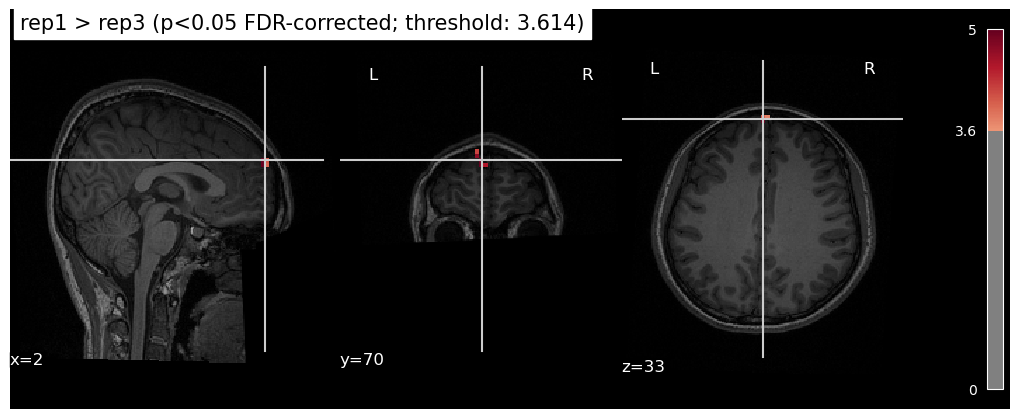

In [55]:
clean_map, threshold = threshold_stats_img(
    z_map, alpha=0.05, height_control="fdr", two_sided=False
)
plot_stat_map(
    clean_map,
    bg_img=anat_img,
    threshold=threshold,
    title=(
        "rep1 > rep3 (p<0.05 FDR-corrected; "
        f"threshold: {threshold:.3f})"
    ),
    figure=plt.figure(figsize=(10, 4)),
)

# Statistical significance testing
There are numerous ways of controlling for type 1 errors, as seen above (threshold, Bonferroni, False discovery rate, discard small voxels). We can also compute F tests and its corresponding map, as opposed to t tests. 

In [56]:
z_map = first_level_model.compute_contrast(
    contrast0,
    output_type="z_score",
    stat_type="F", 
)

/tmp/ipykernel_17662/3624926962.py:1: RuntimeWarning: The same contrast will be used for all 9 runs. If the design matrices are not the same for all runs, (for example with different column names or column order across runs) you should pass contrast as an expression using the name of the conditions as they appear in the design matrices.
  z_map = first_level_model.compute_contrast(


/tmp/ipykernel_17662/3624926962.py:1: UserWarning: Running approximate fixed effects on F statistics.
  z_map = first_level_model.compute_contrast(


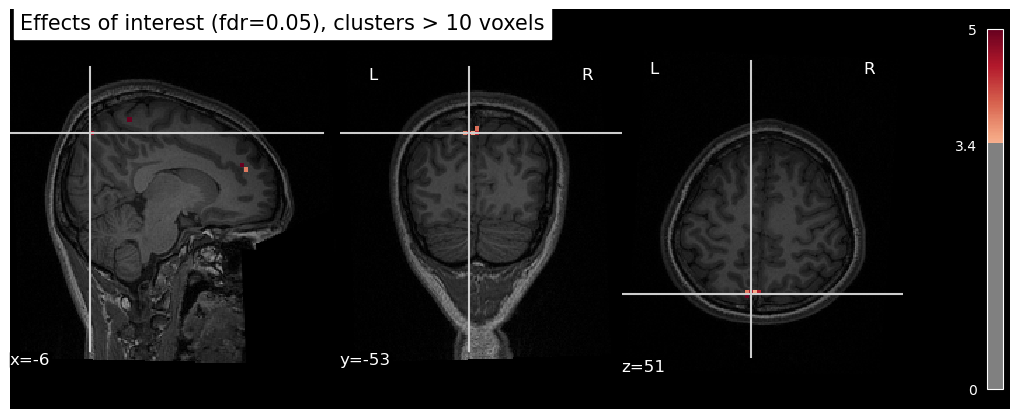

In [57]:
clean_map, threshold = threshold_stats_img(
    z_map,
    alpha=0.05,
    height_control="fdr",
    cluster_threshold=10,
    two_sided=False,
)
plot_stat_map(
    clean_map,
    bg_img=anat_img,
    threshold=threshold,
    title="Effects of interest (fdr=0.05), clusters > 10 voxels",
    figure=plt.figure(figsize=(10, 4)),
)

### Step 6: Tâche 2-B (nouveau dataset)

Les cartes sont affichées aux mêmes coordonnées (0, 0, 0) pour permettre une comparaison intuitive entre les sujets et entre les méthodes statistiques différentes.

> **À NOTER :**
> N'hésitez pas à passer à la section « Step 7: Extract and report findings, Extract and report the found positions in a table »

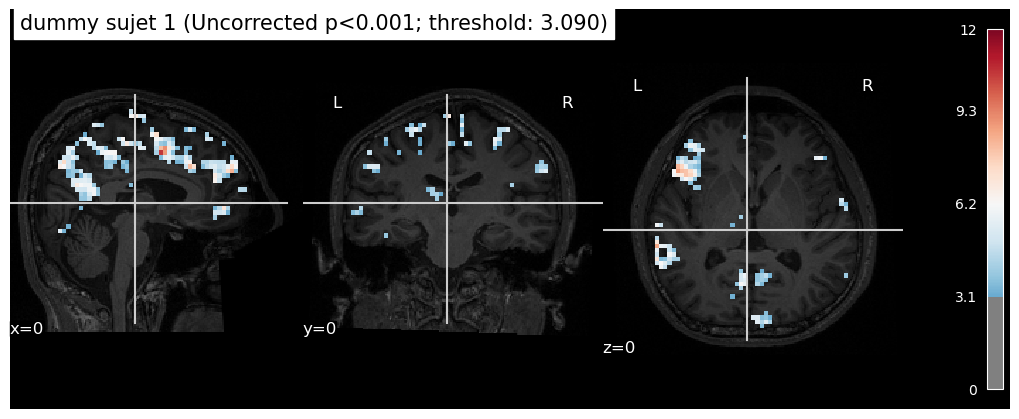

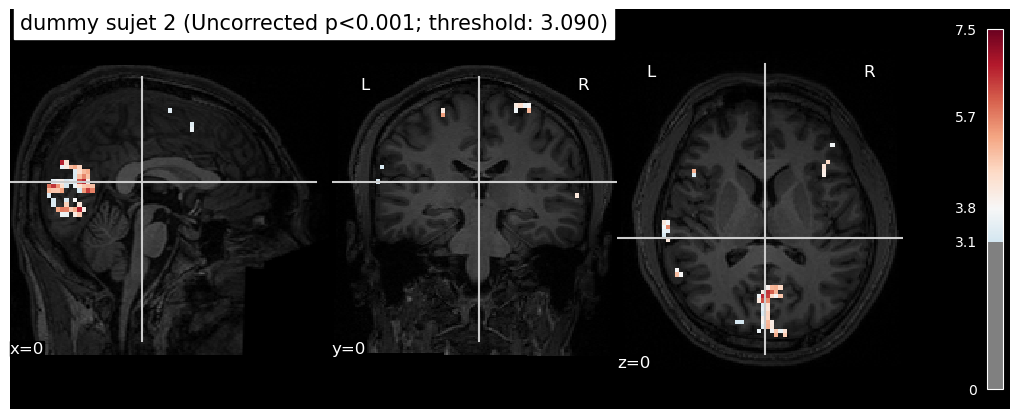

In [35]:
#SUJET 1
clean_map1, threshold1 = threshold_stats_img(
    z_map1,
    alpha=0.001,
    height_control="fpr",
    two_sided=False)

plot_stat_map(
    clean_map1,
    bg_img=anat_img1,
    threshold=threshold1,
    title=(
        "dummy sujet 1 (Uncorrected p<0.001; "
        f"threshold: {threshold1:.3f})"
    ),
    figure=plt.figure(figsize=(10, 4)),
    cut_coords= coordonnees
)


#SUJET 2
clean_map2, threshold2 = threshold_stats_img(
    z_map2,
    alpha=0.001,
    height_control="fpr",
    two_sided=False)

plot_stat_map(
    clean_map2,
    bg_img=anat_img2,
    threshold=threshold2,
    title=(
        "dummy sujet 2 (Uncorrected p<0.001; "
        f"threshold: {threshold2:.3f})"
    ),
    figure=plt.figure(figsize=(10, 4)),
    cut_coords=coordonnees
)


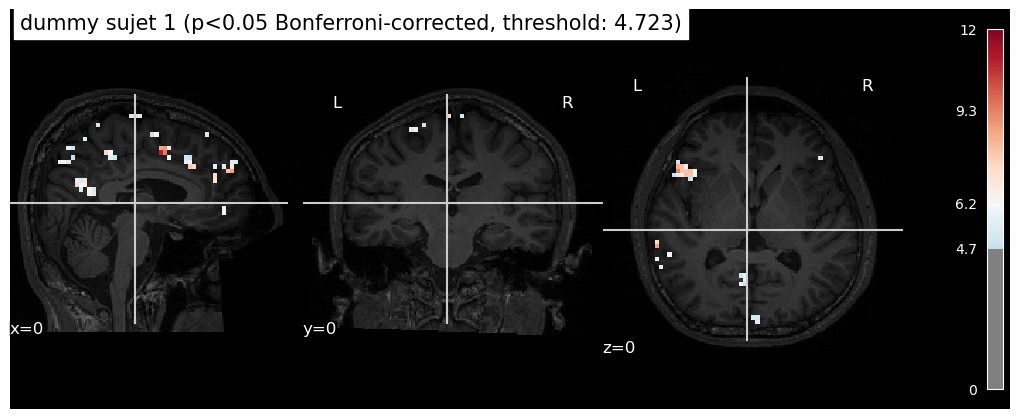

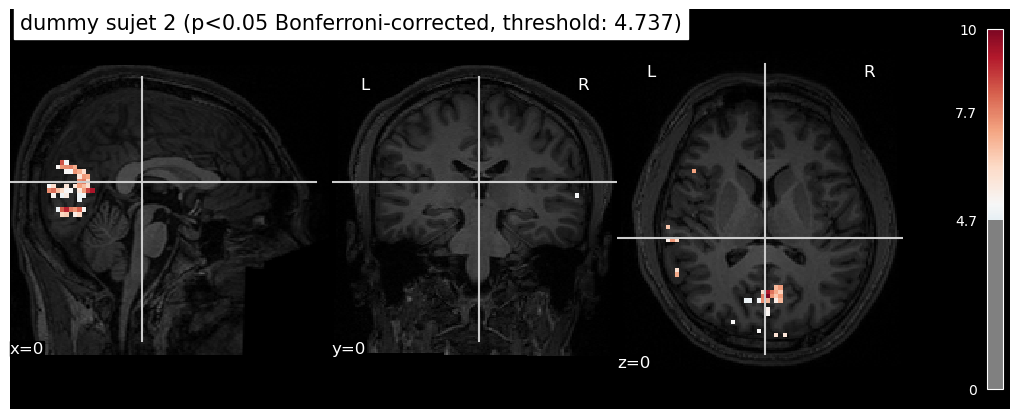

In [59]:
#SUJET 1
clean_map1, threshold1 = threshold_stats_img(
    z_map1, alpha=0.05, height_control="bonferroni", two_sided=False
)
plot_stat_map(
    clean_map1,
    bg_img=anat_img1,
    threshold=threshold1,
    title=(
        "dummy sujet 1 (p<0.05 Bonferroni-corrected, "
        f"threshold: {threshold1:.3f})"
    ),
    figure=plt.figure(figsize=(10, 4)),
    cut_coords=coordonnees
)

#SUJET 2
clean_map2, threshold2 = threshold_stats_img(
    z_map2, alpha=0.05, height_control="bonferroni", two_sided=False
)
plot_stat_map(
    clean_map2,
    bg_img=anat_img2,
    threshold=threshold2,
    title=(
        "dummy sujet 2 (p<0.05 Bonferroni-corrected, "
        f"threshold: {threshold2:.3f})"
    ),
    figure=plt.figure(figsize=(10, 4)),
    cut_coords=coordonnees
)

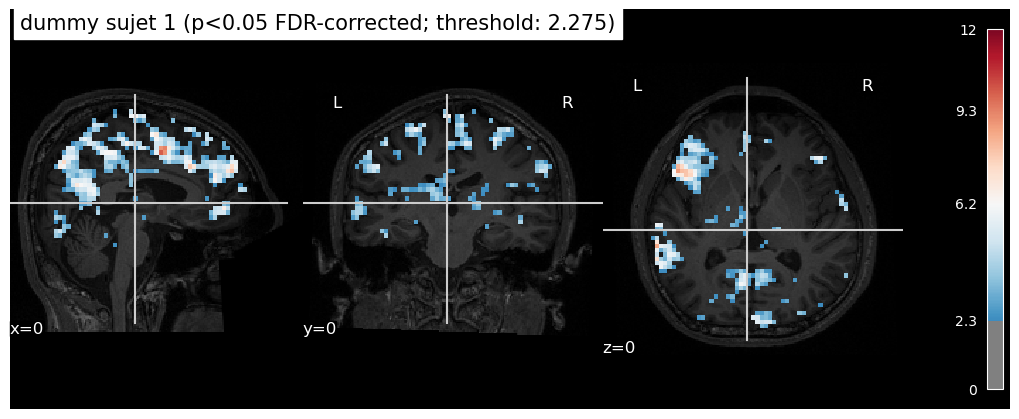

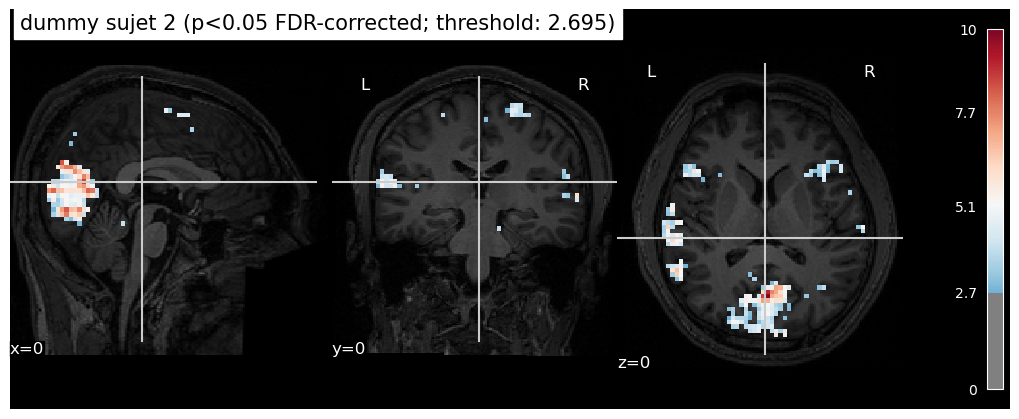

In [60]:
#SUJET 1
clean_map1, threshold1 = threshold_stats_img(
    z_map1, alpha=0.05, height_control="fdr", two_sided=False
)
plot_stat_map(
    clean_map1,
    bg_img=anat_img1,
    threshold=threshold1,
    title=(
        "dummy sujet 1 (p<0.05 FDR-corrected; "
        f"threshold: {threshold1:.3f})"
    ),
    figure=plt.figure(figsize=(10, 4)),
    cut_coords=coordonnees
)


#SUJET 2
clean_map2, threshold2 = threshold_stats_img(
    z_map2, alpha=0.05, height_control="fdr", two_sided=False
)
plot_stat_map(
    clean_map2,
    bg_img=anat_img2,
    threshold=threshold2,
    title=(
        "dummy sujet 2 (p<0.05 FDR-corrected; "
        f"threshold: {threshold2:.3f})"
    ),
    figure=plt.figure(figsize=(10, 4)),
    cut_coords=coordonnees
)

In [ ]:
#SUJET 1
z_map1 = first_level_model1.compute_contrast(
    contrast,
    output_type="z_score",
    stat_type="F", 
)

#SUJET 2
z_map2 = first_level_model2.compute_contrast(
    contrast,
    output_type="z_score",
    stat_type="F", 
)

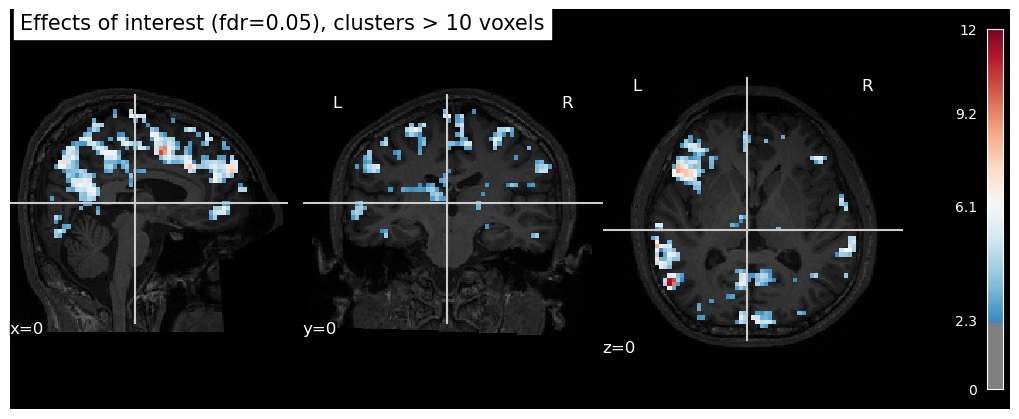

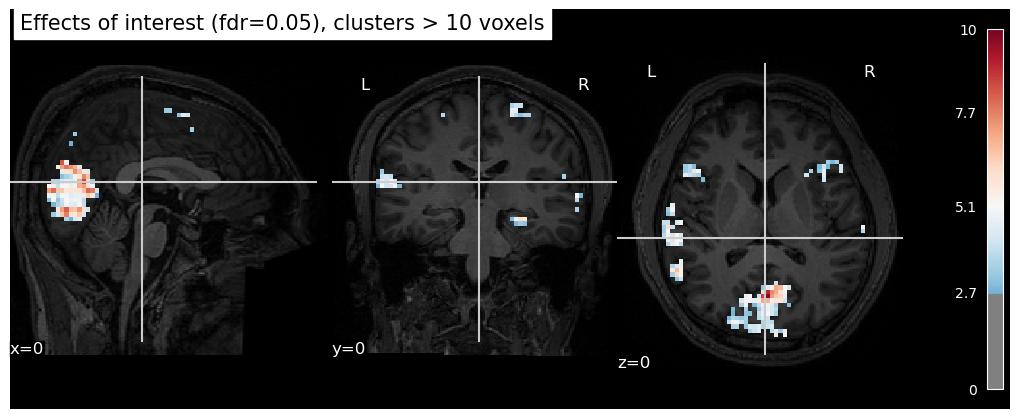

In [62]:
#SUJET 1
clean_map1, threshold1 = threshold_stats_img(
    z_map1,
    alpha=0.05,
    height_control="fdr",
    cluster_threshold=10,
    two_sided=False,
)
plot_stat_map(
    clean_map1,
    bg_img=anat_img1,
    threshold=threshold1,
    title="Effects of interest (fdr=0.05), clusters > 10 voxels",
    figure=plt.figure(figsize=(10, 4)),
    cut_coords=coordonnees
)



#SUJET 2
clean_map2, threshold2 = threshold_stats_img(
    z_map2,
    alpha=0.05,
    height_control="fdr",
    cluster_threshold=10,
    two_sided=False,
)
plot_stat_map(
    clean_map2,
    bg_img=anat_img2,
    threshold=threshold2,
    title="Effects of interest (fdr=0.05), clusters > 10 voxels",
    figure=plt.figure(figsize=(10, 4)),
    cut_coords=coordonnees
)

# Step 7: Extract and report findings
## Extract and report the found positions in a table
This allows us to see any significant clusters so we can report them in a table format. We can play with the cluster threshold and statistical threshold to be more or less conservative.

In [63]:
table = get_clusters_table(
    z_map, stat_threshold=2, cluster_threshold=5
)
table

,Cluster ID,X,Y,Z,Peak Stat,Cluster Size (mm3)
0,1,-8.655678,-54.743089,53.089559,5.006751,6177
1,1a,0.337689,-54.755146,53.434839,4.696022,
2,1b,-17.142325,-60.267043,39.352647,4.299289,
3,1c,9.331056,-51.769031,53.884818,4.054953,
4,2,-39.224443,25.440192,-8.069926,4.874542,1158
...,...,...,...,...,...,...
167,108,-33.608905,37.079594,2.465732,2.508657,207
168,109,40.322383,-53.886726,28.566580,2.479755,148
169,110,-55.100145,9.663840,13.900028,2.475967,178
170,111,52.313536,9.058821,31.225622,2.365834,148


### Step 7: Tâche 2-B (nouveau dataset)

Tableaux de clusters des deux sujets du dataset 2. Permet de comparer les régions activées entre le sujet visual-visual et le sujet audio-visual.

> **À NOTER :**
> N'hésitez pas à passer à la section « Bonus: Make an interactive brain image »

In [64]:
#SUJET 1
table1 = get_clusters_table(
    z_map1, stat_threshold=2, cluster_threshold=5
)
print(table1)

#SUJET 2
table2 = get_clusters_table(
    z_map2, stat_threshold=2, cluster_threshold=5
)
print(table2)

    Cluster ID          X          Y          Z  Peak Stat Cluster Size (mm3)
0            1   2.186697  20.414157  37.378219  12.295504             275526
1           1a -56.197679 -37.864535  -1.375596  11.204965                   
2           1b  50.716490 -28.647652  41.854586  10.893125                   
3           1c -47.781660  44.229109  -3.834053  10.810210                   
4            2  72.679687 -13.323321  -3.689051   7.874615               7632
..         ...        ...        ...        ...        ...                ...
124         84 -35.505355 -42.789636  -9.629752   2.691403                207
125         85  -0.258860 -22.505501 -25.072819   2.660928                237
126         86  41.845068 -34.593425 -25.249406   2.636367                148
127         87  66.397678   8.341871  -7.111887   2.526531                148
128         88   3.457569   4.996831  -4.798207   2.180859                148

[129 rows x 6 columns]


    Cluster ID          X          Y          Z  Peak Stat Cluster Size (mm3)
0            1   2.348012 -40.441820   1.480494  10.208846              48707
1           1a   2.138386 -55.825143  14.229982   9.540557                   
2           1b   5.054706 -61.081031 -12.337493   9.473936                   
3           1c   2.264143 -46.634287   7.899709   8.907143                   
4            2  24.895675  70.009789  11.360050   8.146398               3207
..         ...        ...        ...        ...        ...                ...
187        121 -12.148657  -5.817324  55.330573   2.518120                178
188        122 -48.228730 -10.920288  41.972871   2.509343                148
189        123  12.477641  39.508465  33.565270   2.508888                148
190        124  45.768161  61.112915  -2.109359   2.447669                178
191        125  -9.147650  -3.217384 -33.731453   2.444897                148

[192 rows x 6 columns]


## Bonus: Make an interactive brain image

In [ ]:
vimg = view_img(stat_map_img=z_map, bg_img=anat_img, opacity=0.5, resampling_interpolation='continuous')
vimg

### Bonus: Tâche 2-B (nouveau dataset)

> **À NOTER :**
> N'hésitez pas à ignorer cette section

In [ ]:
#SUJET 1
vimg1 = view_img(stat_map_img=z_map1, bg_img=anat_img1, opacity=0.5, resampling_interpolation='continuous', cut_coords=coordonnees)
vimg1

In [ ]:
#SUJET 2
vimg2 = view_img(stat_map_img=z_map2, bg_img=anat_img2, opacity=0.5, resampling_interpolation='continuous', cut_coords=coordonnees)
vimg2